# Interactive Matplotlib Plot Workshop

Load a scenario once, compute the common plot inputs, then edit each plot directly in its own Matplotlib cell. These cells do not call the package plotting module; they save PDF files and show the Matplotlib output inline.

In [78]:
from pathlib import Path
import calendar
import sys
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.offsetbox import AnchoredOffsetbox, HPacker, TextArea
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "reserve_study").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from reserve_study import ReserveStudy

## Scenario

In [79]:
variant = "2026_board_collab_w_extra_income"
projection_years = 30
current_operating_budget = 480_000

study = ReserveStudy.from_directory(variant)
result = study.run(projection_years=projection_years)
result.write_outputs()

plots_dir = result.scenario.paths.plots_dir
plots_dir.mkdir(parents=True, exist_ok=True)

result.scenario.paths.output_root

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income')

## Plot Data

In [80]:
analysis_year = int(result.scenario.assumptions.analysis_year)
inflation = float(result.scenario.assumptions.inflation)

years = pd.DataFrame({
    "year": np.arange(analysis_year, analysis_year + projection_years, dtype=int),
})

reserve_projection = result.reserve_projection_df()

assessments = result.collection_schedule.annual_df().rename(columns={
    "contribution": "annual_contribution",
})
if assessments.empty:
    assessments = years.assign(annual_contribution=0.0, special_assessment=0.0, additional_income=0.0)
for column in ["annual_contribution", "special_assessment", "additional_income"]:
    if column not in assessments.columns:
        assessments[column] = 0.0
    assessments[column] = pd.to_numeric(assessments[column], errors="coerce").fillna(0.0)
assessments["year"] = pd.to_numeric(assessments["year"], errors="coerce")
assessments = assessments.dropna(subset=["year"]).copy()
assessments["year"] = assessments["year"].astype(int)

expenditures = result.expenditures_summary_df().rename(columns={
    "replacement_year": "year",
})
if expenditures.empty:
    expenditures = years.assign(expenditures=0.0)
expenditures["year"] = pd.to_numeric(expenditures["year"], errors="coerce")
expenditures = expenditures.dropna(subset=["year"]).copy()
expenditures["year"] = expenditures["year"].astype(int)
expenditures["expenditures"] = pd.to_numeric(expenditures["expenditures"], errors="coerce").fillna(0.0)

plot_df = years.merge(
    assessments[["year", "annual_contribution", "special_assessment", "additional_income"]],
    on="year",
    how="left",
)
plot_df = plot_df.merge(expenditures[["year", "expenditures"]], on="year", how="left")
plot_df[["annual_contribution", "special_assessment", "additional_income", "expenditures"]] = plot_df[
    ["annual_contribution", "special_assessment", "additional_income", "expenditures"]
].fillna(0.0)
plot_df["total_contributions"] = (
    plot_df["annual_contribution"] + plot_df["special_assessment"] + plot_df["additional_income"]
)
inflation_factor = (1.0 + inflation) ** (plot_df["year"] - analysis_year)
plot_df["total_contributions_real"] = plot_df["total_contributions"] / inflation_factor
plot_df["expenditures_real"] = plot_df["expenditures"] / inflation_factor
plot_df["cumulative_contributions"] = plot_df["total_contributions"].cumsum()
plot_df["cumulative_contributions_real"] = plot_df["total_contributions_real"].cumsum()
plot_df["cumulative_expenditures"] = plot_df["expenditures"].cumsum()

plot_df.head()


,year,annual_contribution,special_assessment,additional_income,expenditures,total_contributions,total_contributions_real,expenditures_real,cumulative_contributions,cumulative_contributions_real,cumulative_expenditures
0,2026,250000.0,0.0,30000.0,613931.82,280000.0,280000.000000,613931.820000,280000.0,2.800000e+05,613931.82
1,2027,300000.0,0.0,30900.0,301788.46,330900.0,321262.135922,292998.504854,610900.0,6.012621e+05,915720.28
2,2028,350000.0,0.0,31827.0,521771.14,381827.0,359908.568197,491819.342068,992727.0,9.611707e+05,1437491.42
3,2029,400000.0,0.0,32782.0,232889.32,432782.0,396056.837618,213126.718750,1425509.0,1.357228e+06,1670380.74
4,2030,450000.0,0.0,33765.0,353531.52,483765.0,429818.936735,314108.176550,1909274.0,1.787046e+06,2023912.26


In [81]:
reserve_projection.head()

,year,begin_balance,contribution,special_assessment,additional_income,expenditures,interest,end_balance,funded_balance,percent_funded
0,2026,620000.00,250000.0,0.0,30000.0,613931.82,13077.80,299145.98,3284911.06,9.11
1,2027,299145.98,300000.0,0.0,30900.0,301788.46,8923.53,337181.05,3446213.64,9.78
2,2028,337181.05,350000.0,0.0,31827.0,521771.14,8279.26,205516.17,3400168.36,6.04
3,2029,205516.17,400000.0,0.0,32782.0,232889.32,8666.72,414075.57,3652638.38,11.34
4,2030,414075.57,450000.0,0.0,33765.0,353531.52,13374.62,557683.67,3797018.37,14.69


## Small Helpers

In [82]:
money_formatter = mtick.StrMethodFormatter("${x:,.0f}")


def save_pdf(fig, filename):
    path = plots_dir / filename
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="This figure includes Axes that are not compatible")
        fig.tight_layout()
    fig.savefig(path, format="pdf", bbox_inches="tight")
    plt.show()
    return path


def find_milestone_info(df, annual_col, fraction, timeline_start, timeline_end):
    target = df[annual_col].sum() * fraction
    running_before = 0.0

    for _, row in df.iterrows():
        year = int(row["year"])
        annual_val = float(row[annual_col])
        running_after = running_before + annual_val

        if running_after >= target:
            frac_through_year = 0.0 if annual_val == 0 else (target - running_before) / annual_val
            crossing_x = year + frac_through_year
            month_num = min(max(int(frac_through_year * 12) + 1, 1), 12)
            crossing_month_year = f"{calendar.month_name[month_num]} {year}"
            timeline_fraction_x = timeline_start + (timeline_end - timeline_start) * fraction
            delta_years = crossing_x - timeline_fraction_x
            abs_years = abs(delta_years)
            whole_years = int(abs_years)
            whole_months = int(round((abs_years - whole_years) * 12))

            if whole_months == 12:
                whole_years += 1
                whole_months = 0

            if abs_years < 1 / 24:
                timing_text = "On time"
            elif delta_years < 0:
                timing_text = f"{whole_years} years, {whole_months} months early"
            else:
                timing_text = f"{whole_years} years, {whole_months} months late"

            return {"x": crossing_x, "month_year": crossing_month_year, "timing_text": timing_text}

        running_before = running_after

    return {"x": None, "month_year": None, "timing_text": None}

def prepare_b6_maintenance_detail(result, plot_df):
    detail = result.expenditures_detail_df().copy()
    detail["replacement_year"] = pd.to_numeric(
        detail["replacement_year"],
        errors="coerce",
    )
    detail["future_cost"] = pd.to_numeric(
        detail["future_cost"],
        errors="coerce",
    ).fillna(0.0)
    detail = detail.dropna(subset=["replacement_year"]).copy()
    detail["year"] = detail["replacement_year"].astype(int)
    detail = detail[detail["year"].isin(plot_df["year"].astype(int))].copy()

    needs_source_categories = (
        "B6_category" not in detail.columns
        or detail["B6_category"].fillna("").astype(str).str.strip().eq("").all()
    )
    if needs_source_categories:
        source_path = result.scenario.paths.source_data_dir / "component_list_v2.csv"
        source_categories = pd.read_csv(source_path)[["B6_category"]].copy()
        source_categories["component_id"] = source_categories.index
        detail = detail.drop(columns=["B6_category"], errors="ignore").merge(
            source_categories,
            on="component_id",
            how="left",
        )

    if "B6_category" not in detail.columns:
        detail["B6_category"] = "Other"
    detail["planning_category"] = (
        detail["B6_category"]
        .fillna("Other")
        .astype(str)
        .str.strip()
        .replace("", "Other")
    )
    return detail

def b6_planning_categories(detail):
    categories = [
        category
        for category in pd.unique(detail["planning_category"])
        if str(category).strip() and str(category).strip() != "Other"
    ]
    if "Other" in set(detail["planning_category"]):
        categories.append("Other")
    return categories


def b6_category_colors(categories):
    palette = [
        "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
        "#8c564b", "#e377c2", "#bcbd22", "#17becf", "#aec7e8",
        "#ffbb78", "#98df8a", "#ff9896", "#c5b0d5", "#c49c94",
        "#f7b6d2", "#dbdb8d", "#9edae5",
    ]
    color_map = {}
    for index, category in enumerate([c for c in categories if c != "Other"]):
        color_map[category] = palette[index % len(palette)]
    if "Other" in categories:
        color_map["Other"] = "#c7c7c7"
    return color_map


## Reserve Contributions Over Time

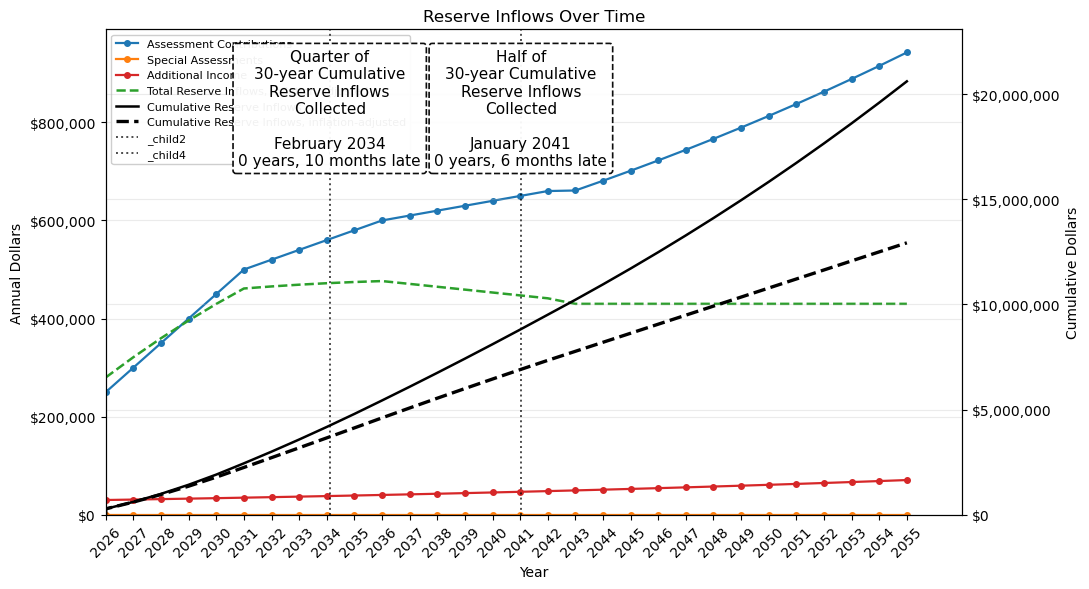

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/reserve_contributions_over_time.pdf')

In [83]:
base_year = analysis_year
last_year = int(plot_df["year"].max())

cumulative_real = plot_df[["year", "total_contributions_real"]].copy()
cumulative_real["cumulative_contributions_real"] = cumulative_real["total_contributions_real"].cumsum()
cumulative_nominal = plot_df[["year", "total_contributions"]].copy()
cumulative_nominal["cumulative_contributions"] = cumulative_nominal["total_contributions"].cumsum()

cumulative_real = pd.concat([
    pd.DataFrame({"year": [base_year], "total_contributions_real": [0.0], "cumulative_contributions_real": [0.0]}),
    cumulative_real,
], ignore_index=True)
cumulative_nominal = pd.concat([
    pd.DataFrame({"year": [base_year], "total_contributions": [0.0], "cumulative_contributions": [0.0]}),
    cumulative_nominal,
], ignore_index=True)

quarter_info = find_milestone_info(plot_df, "total_contributions_real", 0.25, base_year, last_year)
half_info = find_milestone_info(plot_df, "total_contributions_real", 0.50, base_year, last_year)

fig, ax = plt.subplots(figsize=(11, 6))
ax2 = ax.twinx()
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

ax.plot(plot_df["year"], plot_df["annual_contribution"], marker="o", markersize=4, linewidth=1.6, color=colors[0], label="Assessment Contributions")
ax.plot(plot_df["year"], plot_df["special_assessment"], marker="o", markersize=4, linewidth=1.6, color=colors[1], label="Special Assessments")
ax.plot(plot_df["year"], plot_df["additional_income"], marker="o", markersize=4, linewidth=1.6, color=colors[3], label="Additional Income")
ax.plot(plot_df["year"], plot_df["total_contributions_real"], linewidth=1.8, linestyle="--", color=colors[2], label="Total Reserve Inflows, inflation-adjusted")
ax2.plot(cumulative_nominal["year"], cumulative_nominal["cumulative_contributions"], color="black", linewidth=1.8, label="Cumulative Reserve Inflows")
ax2.plot(cumulative_real["year"], cumulative_real["cumulative_contributions_real"], color="black", linewidth=2.4, linestyle="--", label="Cumulative Reserve Inflows, inflation-adjusted")

ax.set_ylim(bottom=0)
cum_max = max(cumulative_nominal["cumulative_contributions"].max(), cumulative_real["cumulative_contributions_real"].max())
ax2.set_ylim(0, cum_max * 1.12 if cum_max else 1.0)

bbox_style = {
    "boxstyle": "round,pad=0.35,rounding_size=0.2",
    "facecolor": "white",
    "edgecolor": "black",
    "linestyle": "--",
    "linewidth": 1.2,
    "alpha": 0.95,
}
for info, headline in [
    (quarter_info, "Quarter of\n30-year Cumulative\nReserve Inflows\nCollected"),
    (half_info, "Half of\n30-year Cumulative\nReserve Inflows\nCollected"),
]:
    if info["x"] is None:
        continue
    ax2.axvline(x=info["x"], color="black", linewidth=1.4, linestyle=":", alpha=0.7)
    ax2.annotate(
        f'{headline}\n\n{info["month_year"]}\n{info["timing_text"]}',
        xy=(info["x"], ax2.get_ylim()[1] * 0.96),
        xytext=(0, 0),
        textcoords="offset points",
        ha="center",
        va="top",
        multialignment="center",
        fontsize=11,
        color="black",
        bbox=bbox_style,
    )

ax.set_title("Reserve Inflows Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Dollars")
ax2.set_ylabel("Cumulative Dollars")
all_years = sorted(set(cumulative_nominal["year"]).union(set(cumulative_real["year"])))
ax.set_xticks(all_years)
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(base_year, plot_df["year"].max() + 2)
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.25)
ax2.grid(True, axis="y", alpha=0.25)
lines = ax.get_lines() + ax2.get_lines()
ax.legend(lines, [line.get_label() for line in lines], loc="upper left", fontsize=8, frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.8")

save_pdf(fig, "reserve_contributions_over_time.pdf")

## Nominal Contributions and Monthly Per-Unit Contributions

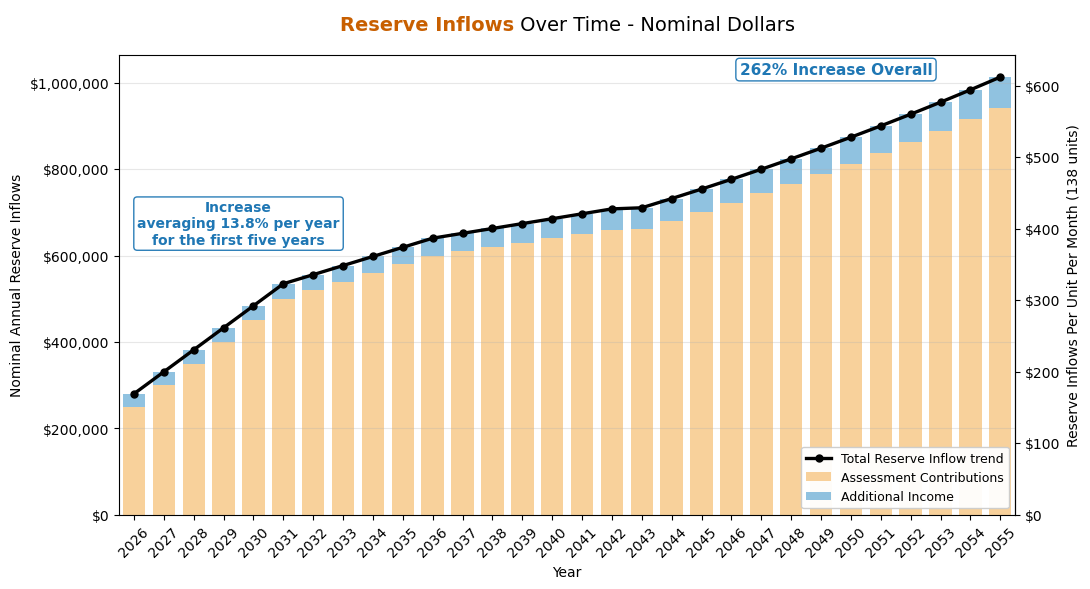

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/nominal_contributions_and_monthly_per_unit.pdf')

In [84]:
units_raw = result.scenario.association_properties.get("NUM_UNITS", "138")
units = int(float(str(units_raw).replace(",", "")))

nominal_plot = plot_df[["year", "annual_contribution", "additional_income", "total_contributions"]].copy()
fig, ax = plt.subplots(figsize=(11, 6))
light_orange = "#f6c27a"
dark_orange = "#c85f00"
additional_income_color = "#6baed6"
total_trend_color = "black"

ax.bar(nominal_plot["year"], nominal_plot["annual_contribution"], width=0.75, color=light_orange, alpha=0.75, label="Assessment Contributions")
ax.bar(nominal_plot["year"], nominal_plot["additional_income"], width=0.75, bottom=nominal_plot["annual_contribution"], color=additional_income_color, alpha=0.75, label="Additional Income")
ax.plot(nominal_plot["year"], nominal_plot["total_contributions"], marker="o", markersize=5, linewidth=2.4, color=total_trend_color, markerfacecolor=total_trend_color, markeredgecolor=total_trend_color, label="Total Reserve Inflow trend")

annual_to_monthly_per_unit = lambda annual_amount: annual_amount / units / 12
monthly_per_unit_to_annual = lambda monthly_amount: monthly_amount * units * 12
ax2 = ax.secondary_yaxis("right", functions=(annual_to_monthly_per_unit, monthly_per_unit_to_annual))
ax.set_title("")
title = HPacker(children=[TextArea("Reserve Inflows", textprops={"color": dark_orange, "fontweight": "bold", "fontsize": 14}), TextArea(" Over Time - Nominal Dollars", textprops={"color": "black", "fontsize": 14})], align="center", pad=0, sep=0)
ax.add_artist(AnchoredOffsetbox(loc="upper center", child=title, bbox_to_anchor=(0.5, 1.10), bbox_transform=ax.transAxes, frameon=False, borderpad=0))
ax.set_xlabel("Year")
ax.set_ylabel("Nominal Annual Reserve Inflows")
ax2.set_ylabel(f"Reserve Inflows Per Unit Per Month ({units:,} units)")
ax.set_xticks(nominal_plot["year"])
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(nominal_plot["year"].min() - 0.5, nominal_plot["year"].max() + 0.5)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(money_formatter)

first_year = int(nominal_plot["year"].min())
fifth_year = first_year + 5
first_five_values = nominal_plot.loc[nominal_plot["year"].between(first_year, fifth_year), ["year", "total_contributions"]].sort_values("year")
first_five_year_average_increase = first_five_values["total_contributions"].pct_change().dropna().head(5).mean() * 100
first_five_annotation_x = (first_year + fifth_year + 2) / 2
first_five_window = nominal_plot[nominal_plot["year"].between(first_year, fifth_year)]
first_five_annotation_y = first_five_window["total_contributions"].max() * 1.16
ax.annotate(f"Increase\naveraging {first_five_year_average_increase:.1f}% per year\nfor the first five years", xy=(first_five_annotation_x, first_five_annotation_y), ha="center", va="bottom", color="#1f77b4", fontweight="bold", fontsize=10, bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "#1f77b4", "alpha": 0.95})
start_reserve = float(nominal_plot.loc[nominal_plot["year"] == 2026, "total_contributions"].iloc[0])
end_reserve = float(nominal_plot.loc[nominal_plot["year"] == 2055, "total_contributions"].iloc[0])
percent_increase = (end_reserve / start_reserve - 1) * 100
annotation_x = (2044 + 2055) / 2
plateau = nominal_plot[nominal_plot["year"].between(2044, 2055)]
annotation_y = plateau["total_contributions"].max() * 1.00
ax.annotate(f"{percent_increase:.0f}% Increase Overall", xy=(annotation_x, annotation_y), ha="center", va="bottom", color="#1f77b4", fontweight="bold", fontsize=11, bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "#1f77b4", "alpha": 0.95})
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="lower right", fontsize=9, frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.8")
save_pdf(fig, "nominal_contributions_and_monthly_per_unit.pdf")


## Reserve and Operating Contributions

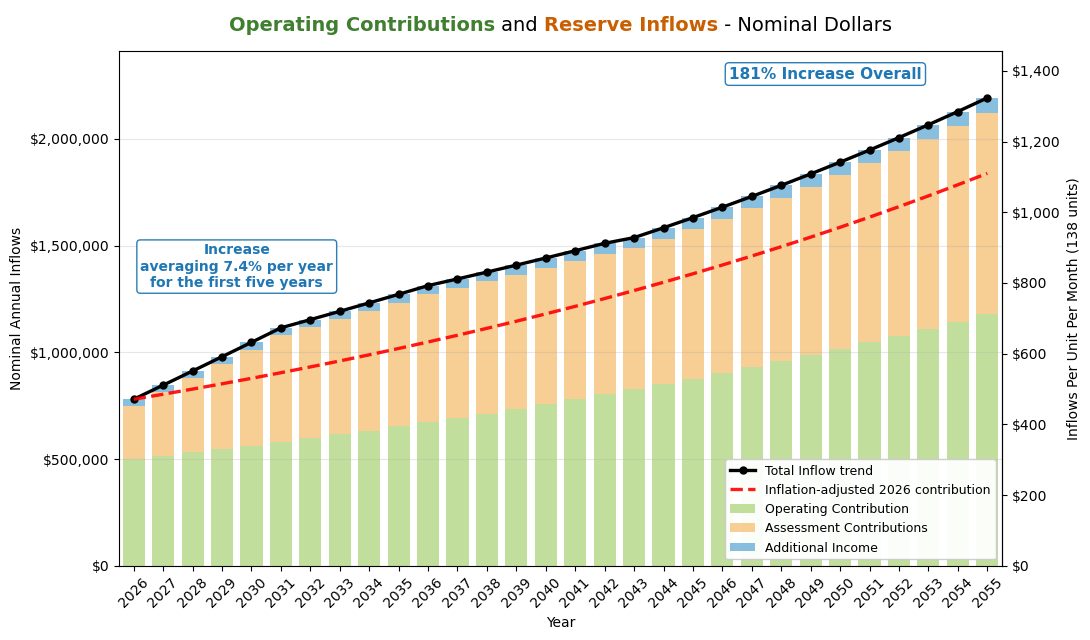

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/reserve_and_operating_contributions.pdf')

In [85]:
units_raw = result.scenario.association_properties.get("NUM_UNITS", "138")
units = int(float(str(units_raw).replace(",", "")))

contribution_stack = plot_df[["year", "annual_contribution", "additional_income"]].copy()
contribution_stack["operating_contribution"] = current_operating_budget * (1.03 ** (contribution_stack["year"] - 2026))
contribution_stack["total_contribution"] = contribution_stack["operating_contribution"] + contribution_stack["annual_contribution"] + contribution_stack["additional_income"]

reserve_axis_max = (contribution_stack["annual_contribution"] + contribution_stack["additional_income"]).max() * 1.1
stacked_axis_max = contribution_stack["total_contribution"].max() * 1.1
height_scale = stacked_axis_max / reserve_axis_max if reserve_axis_max else 1.0
fig_height = min(8.5, 3 * height_scale)

fig, ax = plt.subplots(figsize=(11, fig_height))

light_orange = "#f6c27a"
dark_orange = "#c85f00"
light_green = "#b8d98b"
dark_green = "#3f7f2f"
additional_income_color = "#6baed6"
total_trend_color = "black"

ax.bar(
    contribution_stack["year"],
    contribution_stack["operating_contribution"],
    width=0.75,
    color=light_green,
    alpha=0.85,
    label="Operating Contribution",
)
ax.bar(
    contribution_stack["year"],
    contribution_stack["annual_contribution"],
    width=0.75,
    bottom=contribution_stack["operating_contribution"],
    color=light_orange,
    alpha=0.8,
    label="Assessment Contributions",
)
ax.bar(
    contribution_stack["year"],
    contribution_stack["additional_income"],
    width=0.75,
    bottom=contribution_stack["operating_contribution"] + contribution_stack["annual_contribution"],
    color=additional_income_color,
    alpha=0.8,
    label="Additional Income",
)
ax.plot(
    contribution_stack["year"],
    contribution_stack["total_contribution"],
    marker="o",
    markersize=5,
    linewidth=2.4,
    color=total_trend_color,
    markerfacecolor=total_trend_color,
    markeredgecolor=total_trend_color,
    label="Total Inflow trend",
)

annual_to_monthly_per_unit = lambda annual_amount: annual_amount / units / 12
monthly_per_unit_to_annual = lambda monthly_amount: monthly_amount * units * 12
ax2 = ax.secondary_yaxis(
    "right",
    functions=(annual_to_monthly_per_unit, monthly_per_unit_to_annual),
)

ax.set_title("")
title = HPacker(
    children=[
        TextArea(
            "Operating Contributions",
            textprops={"color": dark_green, "fontweight": "bold", "fontsize": 14},
        ),
        TextArea(
            " and ",
            textprops={"color": "black", "fontsize": 14},
        ),
        TextArea(
            "Reserve Inflows",
            textprops={"color": dark_orange, "fontweight": "bold", "fontsize": 14},
        ),
        TextArea(
            " - Nominal Dollars",
            textprops={"color": "black", "fontsize": 14},
        ),
    ],
    align="center",
    pad=0,
    sep=0,
)
title_box = AnchoredOffsetbox(
    loc="upper center",
    child=title,
    bbox_to_anchor=(0.5, 1.08),
    bbox_transform=ax.transAxes,
    frameon=False,
    borderpad=0,
)
ax.add_artist(title_box)
ax.set_xlabel("Year")
ax.set_ylabel("Nominal Annual Inflows")
ax2.set_ylabel(f"Inflows Per Unit Per Month ({units:,} units)")
ax.set_xticks(contribution_stack["year"])
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(contribution_stack["year"].min() - 0.5, contribution_stack["year"].max() + 0.5)
ax.set_ylim(0, stacked_axis_max)
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(money_formatter)

first_year = int(contribution_stack["year"].min())
fifth_year = first_year + 5
first_five_values = contribution_stack.loc[
    contribution_stack["year"].between(first_year, fifth_year),
    ["year", "total_contribution"],
].sort_values("year")
first_five_year_average_increase = first_five_values["total_contribution"].pct_change().dropna().head(5).mean() * 100
first_five_annotation_x = (first_year + fifth_year + 2) / 2
first_five_window = contribution_stack[
    contribution_stack["year"].between(first_year, fifth_year)
]
first_five_annotation_y = first_five_window["total_contribution"].max() * 1.16
ax.annotate(
    f"Increase\naveraging {first_five_year_average_increase:.1f}% per year\nfor the first five years",
    xy=(first_five_annotation_x, first_five_annotation_y),
    ha="center",
    va="bottom",
    color="#1f77b4",
    fontweight="bold",
    fontsize=10,
    bbox={
        "boxstyle": "round,pad=0.25",
        "facecolor": "white",
        "edgecolor": "#1f77b4",
        "alpha": 0.95,
    },
)

start_combined = float(contribution_stack.loc[contribution_stack["year"] == 2026, "total_contribution"].iloc[0])
end_combined = float(contribution_stack.loc[contribution_stack["year"] == 2055, "total_contribution"].iloc[0])
percent_increase = (end_combined / start_combined - 1) * 100
annotation_x = (2044 + 2055) / 2
plateau = contribution_stack[
    contribution_stack["year"].between(2044, 2055)
]
annotation_y = plateau["total_contribution"].max() * 1.035
ax.annotate(
    f"{percent_increase:.0f}% Increase Overall",
    xy=(annotation_x, annotation_y),
    ha="center",
    va="bottom",
    color="#1f77b4",
    fontweight="bold",
    fontsize=11,
    bbox={
        "boxstyle": "round,pad=0.25",
        "facecolor": "white",
        "edgecolor": "#1f77b4",
        "alpha": 0.95,
    },
)

inflation_only_start_value = float(
    contribution_stack.loc[
        contribution_stack["year"] == 2026,
        "total_contribution",
    ].iloc[0]
)
inflation_only_line = contribution_stack[["year"]].copy()
inflation_only_line = inflation_only_line[inflation_only_line["year"] >= 2026].copy()
inflation_only_line["inflation_adjusted_2026_contribution"] = inflation_only_start_value * (
    1.03 ** (inflation_only_line["year"] - 2026)
)
ax.plot(
    inflation_only_line["year"],
    inflation_only_line["inflation_adjusted_2026_contribution"],
    color="red",
    linestyle="--",
    linewidth=2.4,
    alpha=0.9,
    label="Inflation-adjusted 2026 contribution",
)

ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="lower right", fontsize=9, frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.8")

save_pdf(fig, "reserve_and_operating_contributions.pdf")

## Reserve Contributions in 2026 Purchasing Power

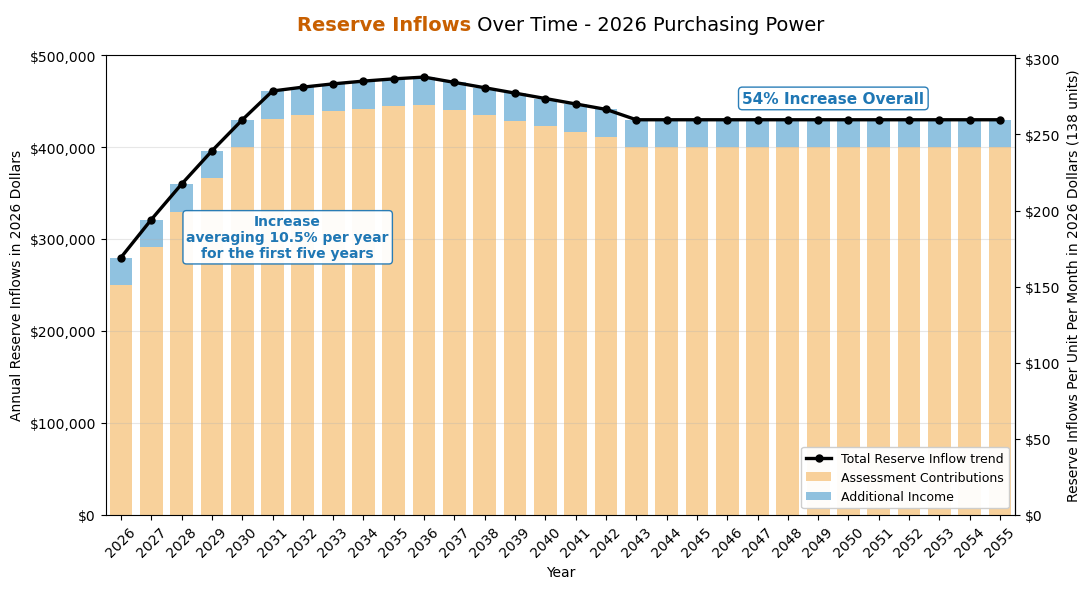

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/real_contributions_and_monthly_per_unit.pdf')

In [86]:
units_raw = result.scenario.association_properties.get("NUM_UNITS", "138")
units = int(float(str(units_raw).replace(",", "")))
real_inflation = 0.03
base_purchasing_power_year = 2026

real_reserve_plot = plot_df[["year", "annual_contribution", "additional_income", "total_contributions"]].copy()
inflation_factor_to_2026 = (1 + real_inflation) ** (real_reserve_plot["year"] - base_purchasing_power_year)
real_reserve_plot["annual_contribution_2026_dollars"] = real_reserve_plot["annual_contribution"] / inflation_factor_to_2026
real_reserve_plot["additional_income_2026_dollars"] = real_reserve_plot["additional_income"] / inflation_factor_to_2026
real_reserve_plot["total_contributions_2026_dollars"] = real_reserve_plot["total_contributions"] / inflation_factor_to_2026
fig, ax = plt.subplots(figsize=(11, 6))
light_orange = "#f6c27a"; dark_orange = "#c85f00"; additional_income_color = "#6baed6"; total_trend_color = "black"
ax.bar(real_reserve_plot["year"], real_reserve_plot["annual_contribution_2026_dollars"], width=0.75, color=light_orange, alpha=0.75, label="Assessment Contributions")
ax.bar(real_reserve_plot["year"], real_reserve_plot["additional_income_2026_dollars"], width=0.75, bottom=real_reserve_plot["annual_contribution_2026_dollars"], color=additional_income_color, alpha=0.75, label="Additional Income")
ax.plot(real_reserve_plot["year"], real_reserve_plot["total_contributions_2026_dollars"], marker="o", markersize=5, linewidth=2.4, color=total_trend_color, markerfacecolor=total_trend_color, markeredgecolor=total_trend_color, label="Total Reserve Inflow trend")
annual_to_monthly_per_unit = lambda annual_amount: annual_amount / units / 12
monthly_per_unit_to_annual = lambda monthly_amount: monthly_amount * units * 12
ax2 = ax.secondary_yaxis("right", functions=(annual_to_monthly_per_unit, monthly_per_unit_to_annual))
ax.set_title("")
title = HPacker(children=[TextArea("Reserve Inflows", textprops={"color": dark_orange, "fontweight": "bold", "fontsize": 14}), TextArea(" Over Time - 2026 Purchasing Power", textprops={"color": "black", "fontsize": 14})], align="center", pad=0, sep=0)
ax.add_artist(AnchoredOffsetbox(loc="upper center", child=title, bbox_to_anchor=(0.5, 1.10), bbox_transform=ax.transAxes, frameon=False, borderpad=0))
ax.set_xlabel("Year"); ax.set_ylabel("Annual Reserve Inflows in 2026 Dollars"); ax2.set_ylabel(f"Reserve Inflows Per Unit Per Month in 2026 Dollars ({units:,} units)")
ax.set_xticks(real_reserve_plot["year"]); ax.tick_params(axis="x", rotation=45)
ax.set_xlim(real_reserve_plot["year"].min() - 0.5, real_reserve_plot["year"].max() + 0.5); ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(money_formatter); ax2.yaxis.set_major_formatter(money_formatter)
first_year = int(real_reserve_plot["year"].min()); fifth_year = first_year + 5
first_five_values = real_reserve_plot.loc[real_reserve_plot["year"].between(first_year, fifth_year), ["year", "total_contributions_2026_dollars"]].sort_values("year")
first_five_year_average_increase = first_five_values["total_contributions_2026_dollars"].pct_change().dropna().head(5).mean() * 100
first_five_annotation_x = (first_year + fifth_year+6) / 2
first_five_window = real_reserve_plot[real_reserve_plot["year"].between(first_year, fifth_year)]
first_five_annotation_y = first_five_window["total_contributions_2026_dollars"].max() * 0.60
ax.annotate(f"Increase\naveraging {first_five_year_average_increase:.1f}% per year\nfor the first five years", xy=(first_five_annotation_x, first_five_annotation_y), ha="center", va="bottom", color="#1f77b4", fontweight="bold", fontsize=10, bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "#1f77b4", "alpha": 0.95})
start_reserve = float(real_reserve_plot.loc[real_reserve_plot["year"] == 2026, "total_contributions_2026_dollars"].iloc[0])
end_reserve = float(real_reserve_plot.loc[real_reserve_plot["year"] == 2055, "total_contributions_2026_dollars"].iloc[0])
percent_increase = (end_reserve / start_reserve - 1) * 100
annotation_x = (2044 + 2055) / 2
plateau = real_reserve_plot[real_reserve_plot["year"].between(2044, 2055)]
annotation_y = plateau["total_contributions_2026_dollars"].max() * 1.035
ax.annotate(f"{percent_increase:.0f}% Increase Overall", xy=(annotation_x, annotation_y), ha="center", va="bottom", color="#1f77b4", fontweight="bold", fontsize=11, bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "#1f77b4", "alpha": 0.95})
ax.grid(True, axis="y", alpha=0.3); ax.legend(loc="lower right", fontsize=9, frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.8")
save_pdf(fig, "real_contributions_and_monthly_per_unit.pdf")


## Reserve and Operating Contributions in 2026 Purchasing Power

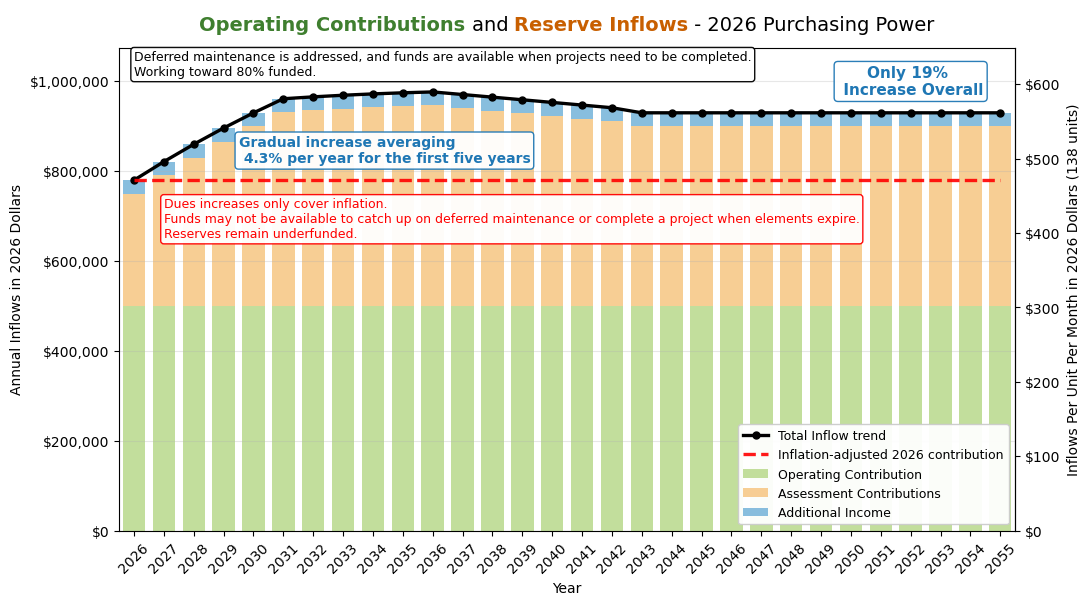

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/reserve_and_operating_contributions_2026_purchasing_power.pdf')

In [87]:
units_raw = result.scenario.association_properties.get("NUM_UNITS", "138")
units = int(float(str(units_raw).replace(",", "")))
real_inflation = 0.03
base_purchasing_power_year = 2026

real_stack = plot_df[["year", "annual_contribution", "additional_income"]].copy()
real_stack["operating_contribution"] = current_operating_budget * (1.03 ** (real_stack["year"] - 2026))
real_stack["inflation_factor_to_2026"] = (1 + real_inflation) ** (real_stack["year"] - base_purchasing_power_year)
real_stack["reserve_contribution_2026_dollars"] = real_stack["annual_contribution"] / real_stack["inflation_factor_to_2026"]
real_stack["additional_income_2026_dollars"] = real_stack["additional_income"] / real_stack["inflation_factor_to_2026"]
real_stack["operating_contribution_2026_dollars"] = real_stack["operating_contribution"] / real_stack["inflation_factor_to_2026"]
real_stack["total_contribution_2026_dollars"] = real_stack["operating_contribution_2026_dollars"] + real_stack["reserve_contribution_2026_dollars"] + real_stack["additional_income_2026_dollars"]

reserve_axis_max = (real_stack["reserve_contribution_2026_dollars"] + real_stack["additional_income_2026_dollars"]).max() * 1.1
stacked_axis_max = real_stack["total_contribution_2026_dollars"].max() * 1.1
height_scale = stacked_axis_max / reserve_axis_max if reserve_axis_max else 1.0
fig_height = min(8.5, 3 * height_scale)

fig, ax = plt.subplots(figsize=(11, fig_height))

light_orange = "#f6c27a"
dark_orange = "#c85f00"
light_green = "#b8d98b"
dark_green = "#3f7f2f"
additional_income_color = "#6baed6"
total_trend_color = "black"

ax.bar(
    real_stack["year"],
    real_stack["operating_contribution_2026_dollars"],
    width=0.75,
    color=light_green,
    alpha=0.85,
    label="Operating Contribution",
)
ax.bar(
    real_stack["year"],
    real_stack["reserve_contribution_2026_dollars"],
    width=0.75,
    bottom=real_stack["operating_contribution_2026_dollars"],
    color=light_orange,
    alpha=0.8,
    label="Assessment Contributions",
)
ax.bar(
    real_stack["year"],
    real_stack["additional_income_2026_dollars"],
    width=0.75,
    bottom=real_stack["operating_contribution_2026_dollars"] + real_stack["reserve_contribution_2026_dollars"],
    color=additional_income_color,
    alpha=0.8,
    label="Additional Income",
)
ax.plot(
    real_stack["year"],
    real_stack["total_contribution_2026_dollars"],
    marker="o",
    markersize=5,
    linewidth=2.4,
    color=total_trend_color,
    markerfacecolor=total_trend_color,
    markeredgecolor=total_trend_color,
    label="Total Inflow trend",
)

annual_to_monthly_per_unit = lambda annual_amount: annual_amount / units / 12
monthly_per_unit_to_annual = lambda monthly_amount: monthly_amount * units * 12
ax2 = ax.secondary_yaxis(
    "right",
    functions=(annual_to_monthly_per_unit, monthly_per_unit_to_annual),
)

ax.set_title("")
title = HPacker(
    children=[
        TextArea(
            "Operating Contributions",
            textprops={"color": dark_green, "fontweight": "bold", "fontsize": 14},
        ),
        TextArea(
            " and ",
            textprops={"color": "black", "fontsize": 14},
        ),
        TextArea(
            "Reserve Inflows",
            textprops={"color": dark_orange, "fontweight": "bold", "fontsize": 14},
        ),
        TextArea(
            " - 2026 Purchasing Power",
            textprops={"color": "black", "fontsize": 14},
        ),
    ],
    align="center",
    pad=0,
    sep=0,
)
title_box = AnchoredOffsetbox(
    loc="upper center",
    child=title,
    bbox_to_anchor=(0.5, 1.08),
    bbox_transform=ax.transAxes,
    frameon=False,
    borderpad=0,
)
ax.add_artist(title_box)
ax.set_xlabel("Year")
ax.set_ylabel("Annual Inflows in 2026 Dollars")
ax2.set_ylabel(f"Inflows Per Unit Per Month in 2026 Dollars ({units:,} units)")
ax.set_xticks(real_stack["year"])
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(real_stack["year"].min() - 0.5, real_stack["year"].max() + 0.5)
ax.set_ylim(0, stacked_axis_max)
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(money_formatter)

first_year = int(real_stack["year"].min())
fifth_year = first_year + 5
first_five_values = real_stack.loc[
    real_stack["year"].between(first_year, fifth_year),
    ["year", "total_contribution_2026_dollars"],
].sort_values("year")
first_five_year_average_increase = first_five_values["total_contribution_2026_dollars"].pct_change().dropna().head(5).mean() * 100
first_five_annotation_x = (first_year + fifth_year +2 ) / 2
first_five_window = real_stack[
    real_stack["year"].between(first_year, fifth_year)
]
first_five_annotation_y = first_five_window["total_contribution_2026_dollars"].max() * 0.88
ax.annotate(
    f"Gradual increase averaging\n {first_five_year_average_increase:.1f}% per year for the first five years",
    xy=(first_five_annotation_x, first_five_annotation_y),
    ha="left",
    va="center",
    color="#1f77b4",
    fontweight="bold",
    fontsize=10,
    bbox={
        "boxstyle": "round,pad=0.25",
        "facecolor": "white",
        "edgecolor": "#1f77b4",
        "alpha": 0.95,
    },
)

start_combined = float(real_stack.loc[real_stack["year"] == 2026, "total_contribution_2026_dollars"].iloc[0])
end_combined = float(real_stack.loc[real_stack["year"] == 2055, "total_contribution_2026_dollars"].iloc[0])
percent_increase = (end_combined / start_combined - 1) * 100
annotation_x = 2052
plateau = real_stack[
    real_stack["year"].between(2044, 2055)
]
annotation_y = plateau["total_contribution_2026_dollars"].max() * 1.075
ax.annotate(
    f"Only {percent_increase:.0f}% \n Increase Overall",
    xy=(annotation_x, annotation_y),
    ha="center",
    va="center",
    color="#1f77b4",
    fontweight="bold",
    fontsize=11,
    bbox={
        "boxstyle": "round,pad=0.25",
        "facecolor": "white",
        "edgecolor": "#1f77b4",
        "alpha": 0.95,
    },
)

policy_text_fontsize = 9
inflation_only_value = float(
    real_stack.loc[
        real_stack["year"] == 2026,
        "total_contribution_2026_dollars",
    ].iloc[0]
)
inflation_only_line = real_stack[["year"]].copy()
inflation_only_line = inflation_only_line[inflation_only_line["year"] >= 2026].copy()
inflation_only_line["inflation_adjusted_2026_contribution"] = inflation_only_value
ax.plot(
    inflation_only_line["year"],
    inflation_only_line["inflation_adjusted_2026_contribution"],
    color="red",
    linestyle="--",
    linewidth=2.4,
    alpha=0.9,
    label="Inflation-adjusted 2026 contribution",
)
ax.annotate(
    "Dues increases only cover inflation.\n"
    "Funds may not be available to catch up on deferred maintenance or complete a project when elements expire.\n"
    "Reserves remain underfunded.",
    xy=(2027, inflation_only_value * 0.95),
    ha="left",
    va="top",
    color="red",
    fontsize=policy_text_fontsize,
    bbox={
        "boxstyle": "round,pad=0.25",
        "facecolor": "white",
        "edgecolor": "red",
        "alpha": 0.95,
    },
)
ax.annotate(
    "Deferred maintenance is addressed, and funds are available when projects need to be completed.\n"
    "Working toward 80% funded.",
    xy=(2026, inflation_only_value * 1.29),
    ha="left",
    va="bottom",
    color="black",
    fontsize=policy_text_fontsize,
    bbox={
        "boxstyle": "round,pad=0.25",
        "facecolor": "white",
        "edgecolor": "black",
        "alpha": 0.95,
    },
)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="lower right", fontsize=9, frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.8")

save_pdf(fig, "reserve_and_operating_contributions_2026_purchasing_power.pdf")

## Expenditures and Total Contributions

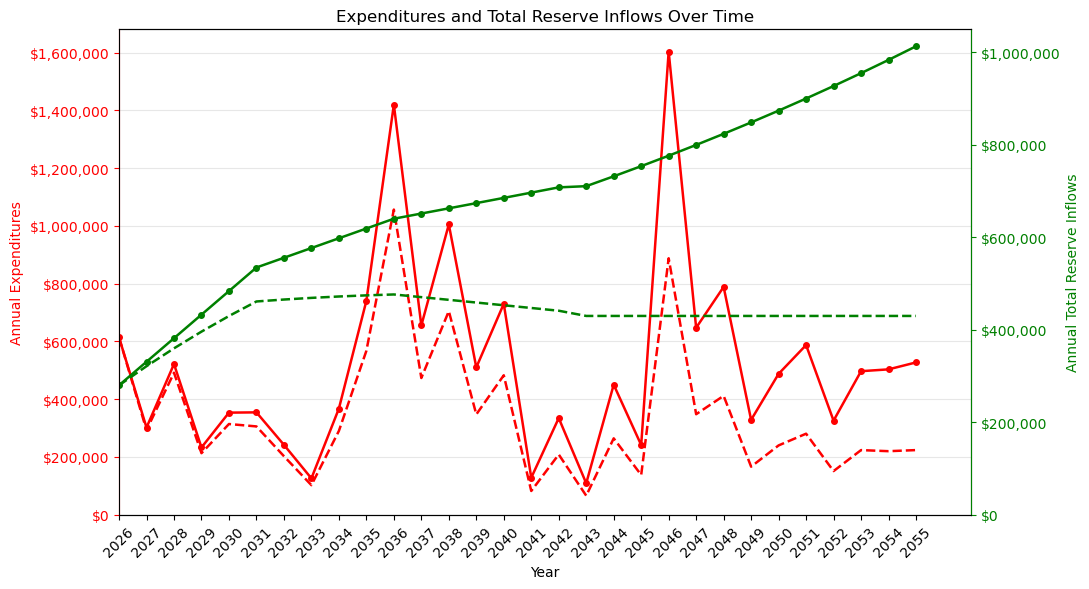

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/expenditures_and_total_contributions.pdf')

In [88]:
fig, ax = plt.subplots(figsize=(11, 6))
ax2 = ax.twinx()

exp_color = "red"
contrib_color = "green"

ax.plot(plot_df["year"], plot_df["expenditures"], marker="o", markersize=4, linewidth=1.8, linestyle="-", color=exp_color)
ax.plot(plot_df["year"], plot_df["expenditures_real"], linewidth=1.8, linestyle="--", color=exp_color)
ax2.plot(plot_df["year"], plot_df["total_contributions"], marker="o", markersize=4, linewidth=1.8, linestyle="-", color=contrib_color)
ax2.plot(plot_df["year"], plot_df["total_contributions_real"], linewidth=1.8, linestyle="--", color=contrib_color)

ax.set_title("Expenditures and Total Reserve Inflows Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Expenditures", color=exp_color)
ax2.set_ylabel("Annual Total Reserve Inflows", color=contrib_color)
ax.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax.set_xticks(sorted(plot_df["year"].unique()))
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", colors=exp_color)
ax2.tick_params(axis="y", colors=contrib_color)
ax.spines["left"].set_color(exp_color)
ax2.spines["right"].set_color(contrib_color)
ax.yaxis.label.set_color(exp_color)
ax2.yaxis.label.set_color(contrib_color)
ax.set_xlim(plot_df["year"].min(), plot_df["year"].max() + 2)
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.3)

save_pdf(fig, "expenditures_and_total_contributions.pdf")

## Annual and Cumulative Expenditures vs. Contributions

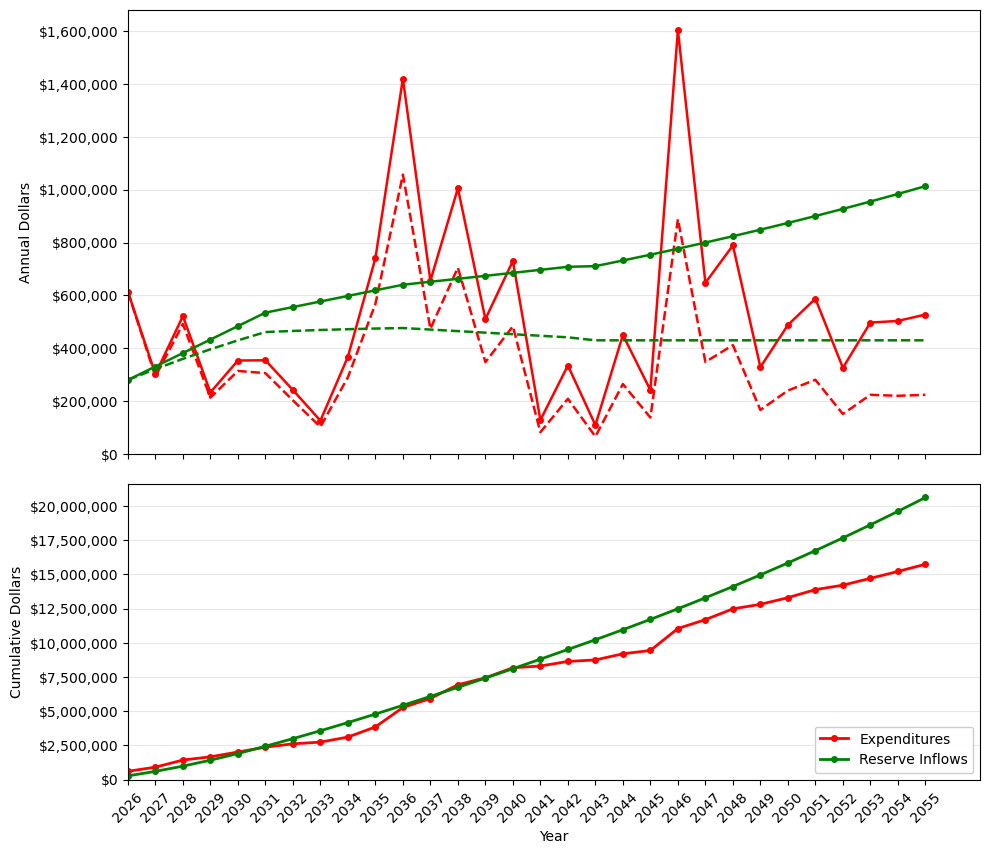

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/annual_and_cumulative_expenditures_vs_contributions.pdf')

In [89]:
exp_color = "red"
contrib_color = "green"

fig, (ax, ax_bottom) = plt.subplots(
    2,
    1,
    figsize=(11, 10),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 2], "hspace": 0.08},
)

ax.plot(plot_df["year"], plot_df["expenditures"], marker="o", markersize=4, linewidth=1.8, linestyle="-", color=exp_color)
ax.plot(plot_df["year"], plot_df["expenditures_real"], linewidth=1.8, linestyle="--", color=exp_color)
ax.plot(plot_df["year"], plot_df["total_contributions"], marker="o", markersize=4, linewidth=1.8, linestyle="-", color=contrib_color)
ax.plot(plot_df["year"], plot_df["total_contributions_real"], linewidth=1.8, linestyle="--", color=contrib_color)
ax.set_ylabel("Annual Dollars")
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.3)

line_exp, = ax_bottom.plot(plot_df["year"], plot_df["cumulative_expenditures"], marker="o", markersize=4, linewidth=2.0, linestyle="-", color=exp_color, label="Expenditures")
line_contrib, = ax_bottom.plot(plot_df["year"], plot_df["cumulative_contributions"], marker="o", markersize=4, linewidth=2.0, linestyle="-", color=contrib_color, label="Reserve Inflows")
ax_bottom.set_xlabel("Year")
ax_bottom.set_ylabel("Cumulative Dollars")
ax_bottom.set_ylim(bottom=0)
ax_bottom.yaxis.set_major_formatter(money_formatter)
ax_bottom.grid(True, axis="y", alpha=0.3)
ax_bottom.set_xticks(sorted(plot_df["year"].unique()))
ax_bottom.tick_params(axis="x", rotation=45)
ax_bottom.set_xlim(plot_df["year"].min(), plot_df["year"].max() + 2)
ax_bottom.legend(handles=[line_exp, line_contrib], loc="lower right", frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.8")

save_pdf(fig, "annual_and_cumulative_expenditures_vs_contributions.pdf")

## Annual and Cumulative Reserve Contributions

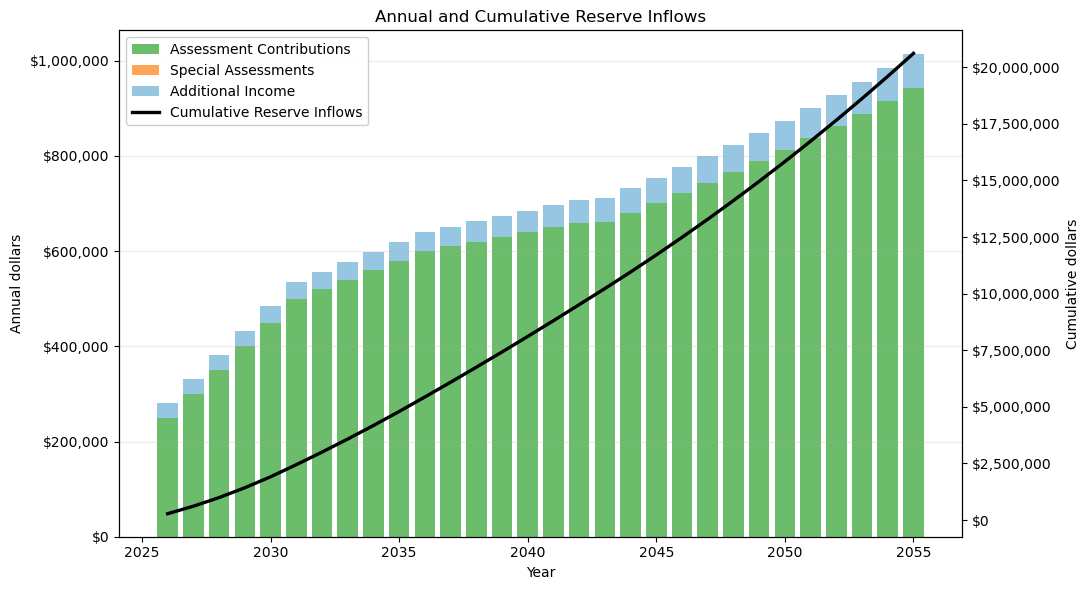

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/stacked_contributions_vs_cumulative.pdf')

In [90]:
fig, ax = plt.subplots(figsize=(11, 6))
bar_bottom = np.zeros(len(plot_df))
for column, label, color in [("annual_contribution", "Assessment Contributions", "#2ca02c"), ("special_assessment", "Special Assessments", "#ff7f0e"), ("additional_income", "Additional Income", "#6baed6")]:
    ax.bar(plot_df["year"], plot_df[column], bottom=bar_bottom, color=color, alpha=0.7, label=label)
    bar_bottom += plot_df[column].to_numpy(dtype=float)
ax2 = ax.twinx()
ax2.plot(plot_df["year"], plot_df["cumulative_contributions"], color="black", linewidth=2.4, label="Cumulative Reserve Inflows")
ax.set_title("Annual and Cumulative Reserve Inflows")
ax.set_xlabel("Year"); ax.set_ylabel("Annual dollars"); ax2.set_ylabel("Cumulative dollars")
ax.yaxis.set_major_formatter(money_formatter); ax2.yaxis.set_major_formatter(money_formatter); ax.grid(True, axis="y", alpha=0.25)
handles1, labels1 = ax.get_legend_handles_labels(); handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, loc="upper left", frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.8")
save_pdf(fig, "stacked_contributions_vs_cumulative.pdf")


## Annual and Cumulative Contributions and Expenditures

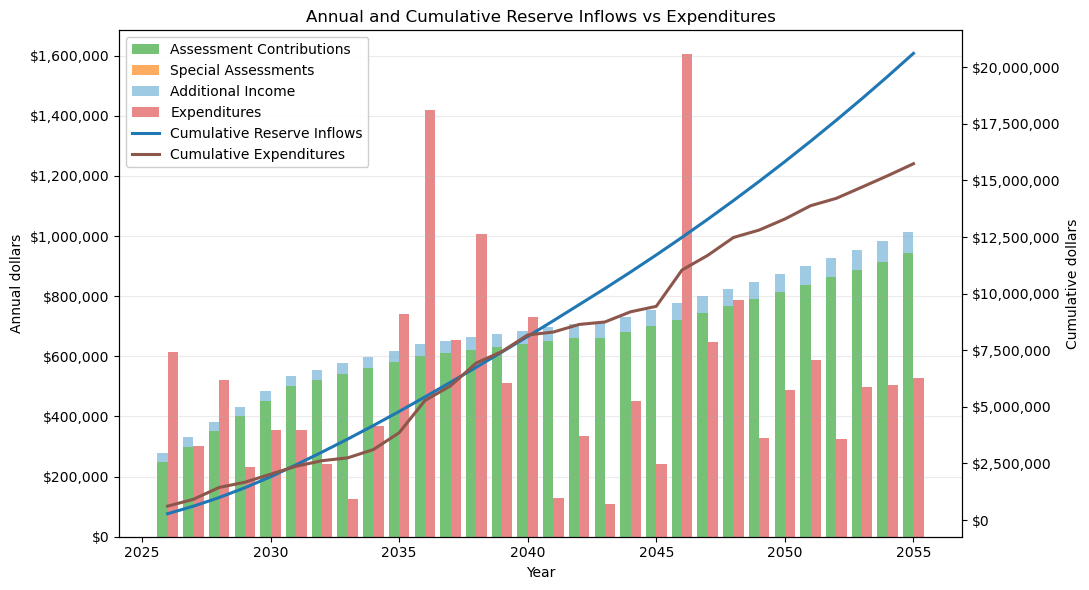

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/contributions_expenditures_cumulative.pdf')

In [91]:
fig, ax = plt.subplots(figsize=(11, 6))
bar_bottom = np.zeros(len(plot_df))
for column, label, color in [("annual_contribution", "Assessment Contributions", "#2ca02c"), ("special_assessment", "Special Assessments", "#ff7f0e"), ("additional_income", "Additional Income", "#6baed6")]:
    ax.bar(plot_df["year"] - 0.2, plot_df[column], width=0.4, bottom=bar_bottom, color=color, alpha=0.65, label=label)
    bar_bottom += plot_df[column].to_numpy(dtype=float)
ax.bar(plot_df["year"] + 0.2, plot_df["expenditures"], width=0.4, color="#d62728", alpha=0.55, label="Expenditures")
ax2 = ax.twinx()
ax2.plot(plot_df["year"], plot_df["cumulative_contributions"], color="#1f77b4", linewidth=2.2, label="Cumulative Reserve Inflows")
ax2.plot(plot_df["year"], plot_df["cumulative_expenditures"], color="#8c564b", linewidth=2.2, label="Cumulative Expenditures")
ax.set_title("Annual and Cumulative Reserve Inflows vs Expenditures")
ax.set_xlabel("Year"); ax.set_ylabel("Annual dollars"); ax2.set_ylabel("Cumulative dollars")
ax.yaxis.set_major_formatter(money_formatter); ax2.yaxis.set_major_formatter(money_formatter); ax.grid(True, axis="y", alpha=0.25)
handles1, labels1 = ax.get_legend_handles_labels(); handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, loc="upper left", frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.8")
save_pdf(fig, "contributions_expenditures_cumulative.pdf")


## Big Six Component Categorization Table


In [92]:
big_six_detail = prepare_b6_maintenance_detail(result, plot_df)

big_six_component_table = (
    big_six_detail[big_six_detail["planning_category"] != "Other"]
    .assign(B6_category=big_six_detail["planning_category"])
    [["B6_category", "category", "subcategory", "component"]]
    .drop_duplicates()
    .sort_values(["B6_category", "category", "subcategory", "component"])
    .reset_index(drop=True)
)
big_six_component_table


,B6_category,category,subcategory,component
0,Balconies,Balconies-Decks-Stairways,Railings,Stairway/Balcony Railing
1,Balconies,Balconies-Decks-Stairways,Structural,Balconies-Decks-Posts/Structural Supports
2,Balconies,Balconies-Decks-Stairways,Structural,Wood Balcony Walls
3,Carports,Roofing,Metal,Carport Roofs
4,Carports,Structural,Metal,Carport Support Posts-Beams
...,...,...,...,...
64,Siding,Exterior Surfaces,Siding,Stucco Siding Repair
65,Sloped Roofs,Roofing,Inspection,Roof Inspection and Repair
66,Sloped Roofs,Roofing,Shingle,Clubhouse Roof
67,Sloped Roofs,Roofing,Shingle,Unit Building Shingle Roofs


## The Big Six and Reserve Balance

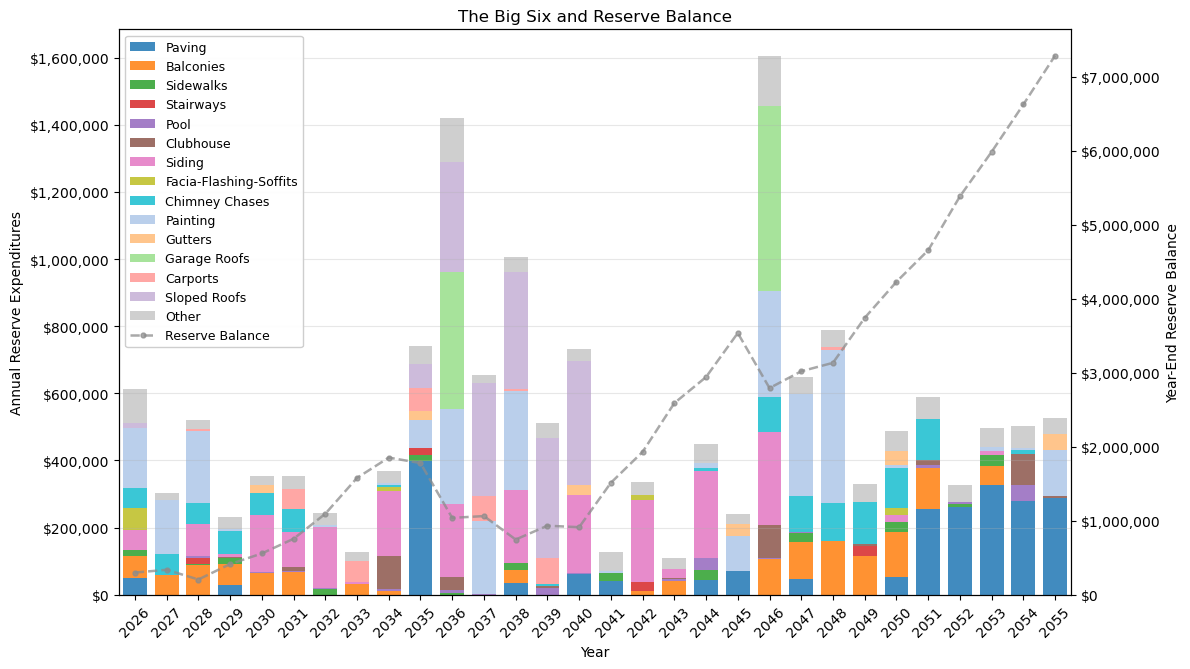

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/maintenance_planning_big_components_and_reserve_balance.pdf')

In [93]:
maintenance_detail = prepare_b6_maintenance_detail(result, plot_df)
planning_years = pd.DataFrame({"year": plot_df["year"].astype(int)})
planning_categories = b6_planning_categories(maintenance_detail)
named_project_categories = planning_categories
category_colors = b6_category_colors(planning_categories)

maintenance_by_category = (
    maintenance_detail[maintenance_detail["year"].isin(planning_years["year"])]
    .groupby(["year", "planning_category"], as_index=False)["future_cost"]
    .sum()
)
maintenance_matrix = (
    maintenance_by_category.pivot_table(
        index="year",
        columns="planning_category",
        values="future_cost",
        aggfunc="sum",
        fill_value=0.0,
    )
    .reindex(index=planning_years["year"], columns=planning_categories, fill_value=0.0)
    .reset_index()
)

reserve_balance_plot = reserve_projection[["year", "end_balance"]].copy()
reserve_balance_plot["year"] = pd.to_numeric(reserve_balance_plot["year"], errors="coerce").astype(int)
reserve_balance_plot["end_balance"] = pd.to_numeric(
    reserve_balance_plot["end_balance"],
    errors="coerce",
).fillna(0.0)

fig, ax = plt.subplots(figsize=(12, 6.8))
ax2 = ax.twinx()


bar_bottom = np.zeros(len(maintenance_matrix))
for category in planning_categories:
    values = maintenance_matrix[category].to_numpy(dtype=float)
    ax.bar(
        maintenance_matrix["year"],
        values,
        width=0.75,
        bottom=bar_bottom,
        color=category_colors[category],
        alpha=0.85,
        label=category,
    )
    bar_bottom += values

ax2.plot(
    reserve_balance_plot["year"],
    reserve_balance_plot["end_balance"],
    color="0.55",
    linestyle="--",
    marker="o",
    markersize=3.5,
    linewidth=1.8,
    alpha=0.75,
    label="Reserve Balance",
)

ax.set_title("The Big Six and Reserve Balance")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Reserve Expenditures")
ax2.set_ylabel("Year-End Reserve Balance")
ax.set_xticks(maintenance_matrix["year"])
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(maintenance_matrix["year"].min() - 0.5, maintenance_matrix["year"].max() + 0.5)
ax.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.3)

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    fontsize=9,
    frameon=True,
    facecolor="white",
    framealpha=0.95,
    edgecolor="0.8",
)

save_pdf(fig, "maintenance_planning_big_components_and_reserve_balance.pdf")


## The Big Six and Reserve Balance

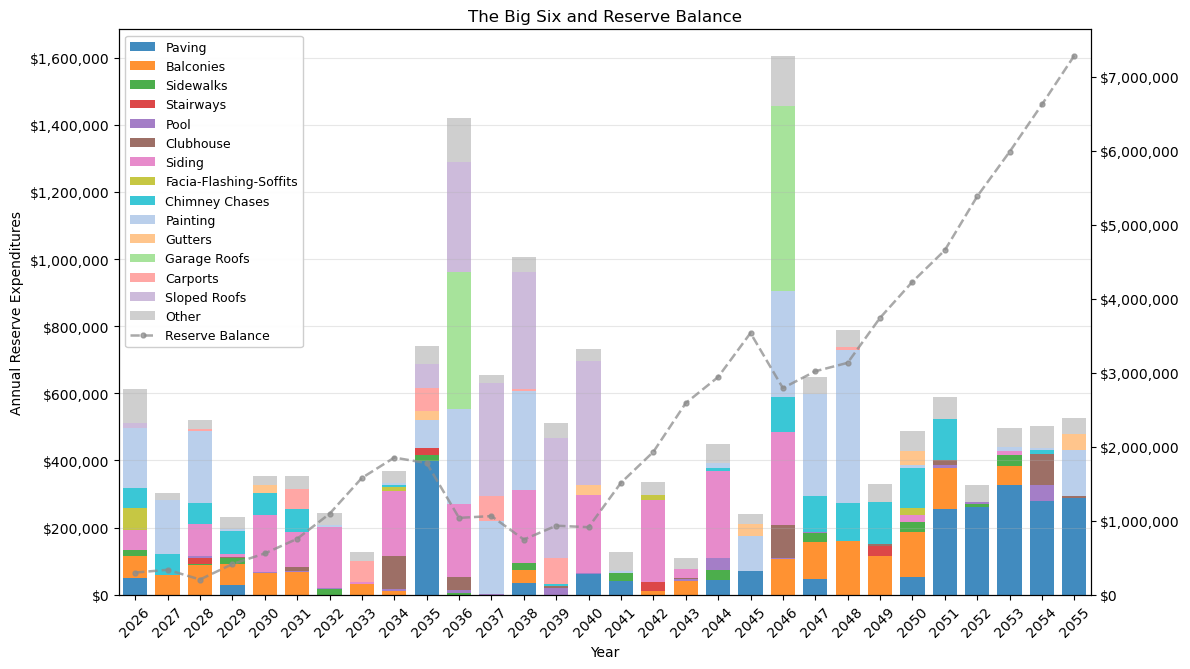

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/maintenance_planning_selected_categories_and_reserve_balance.pdf')

In [94]:
maintenance_detail = prepare_b6_maintenance_detail(result, plot_df)
planning_years = pd.DataFrame({"year": plot_df["year"].astype(int)})
planning_categories = b6_planning_categories(maintenance_detail)
named_project_categories = planning_categories
category_colors = b6_category_colors(planning_categories)

maintenance_by_category = (
    maintenance_detail[maintenance_detail["year"].isin(planning_years["year"])]
    .groupby(["year", "planning_category"], as_index=False)["future_cost"]
    .sum()
)
maintenance_matrix = (
    maintenance_by_category.pivot_table(
        index="year",
        columns="planning_category",
        values="future_cost",
        aggfunc="sum",
        fill_value=0.0,
    )
    .reindex(index=planning_years["year"], columns=planning_categories, fill_value=0.0)
    .reset_index()
)
reserve_balance_plot = reserve_projection[["year", "end_balance"]].copy()
reserve_balance_plot["year"] = pd.to_numeric(reserve_balance_plot["year"], errors="coerce").astype(int)
reserve_balance_plot["end_balance"] = pd.to_numeric(
    reserve_balance_plot["end_balance"],
    errors="coerce",
).fillna(0.0)

maintenance_matrix = maintenance_matrix.merge(reserve_balance_plot, on="year", how="left")
maintenance_matrix["end_balance"] = maintenance_matrix["end_balance"].fillna(0.0)
fig, ax = plt.subplots(figsize=(12, 6.8))
ax2 = ax.twinx()

bar_bottom = np.zeros(len(maintenance_matrix))
for category in planning_categories:
    values = maintenance_matrix[category].to_numpy(dtype=float)
    ax.bar(
        maintenance_matrix["year"],
        values,
        width=0.75,
        bottom=bar_bottom,
        color=category_colors[category],
        alpha=0.85,
        label=category,
    )
    bar_bottom += values

ax2.plot(
    reserve_balance_plot["year"],
    reserve_balance_plot["end_balance"],
    color="0.55",
    linestyle="--",
    marker="o",
    markersize=3.5,
    linewidth=1.8,
    alpha=0.75,
    label="Reserve Balance",
)

ax.set_title("The Big Six and Reserve Balance")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Reserve Expenditures")
ax2.set_ylabel("")
ax.set_xticks(maintenance_matrix["year"])
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(maintenance_matrix["year"].min() - 0.5, maintenance_matrix["year"].max() + 0.5)
ax.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.3)

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    fontsize=9,
    frameon=True,
    facecolor="white",
    framealpha=0.95,
    edgecolor="0.8",
)

save_pdf(fig, "maintenance_planning_selected_categories_and_reserve_balance.pdf")


## The Big Six and Reserve Balance in 2026 Dollars

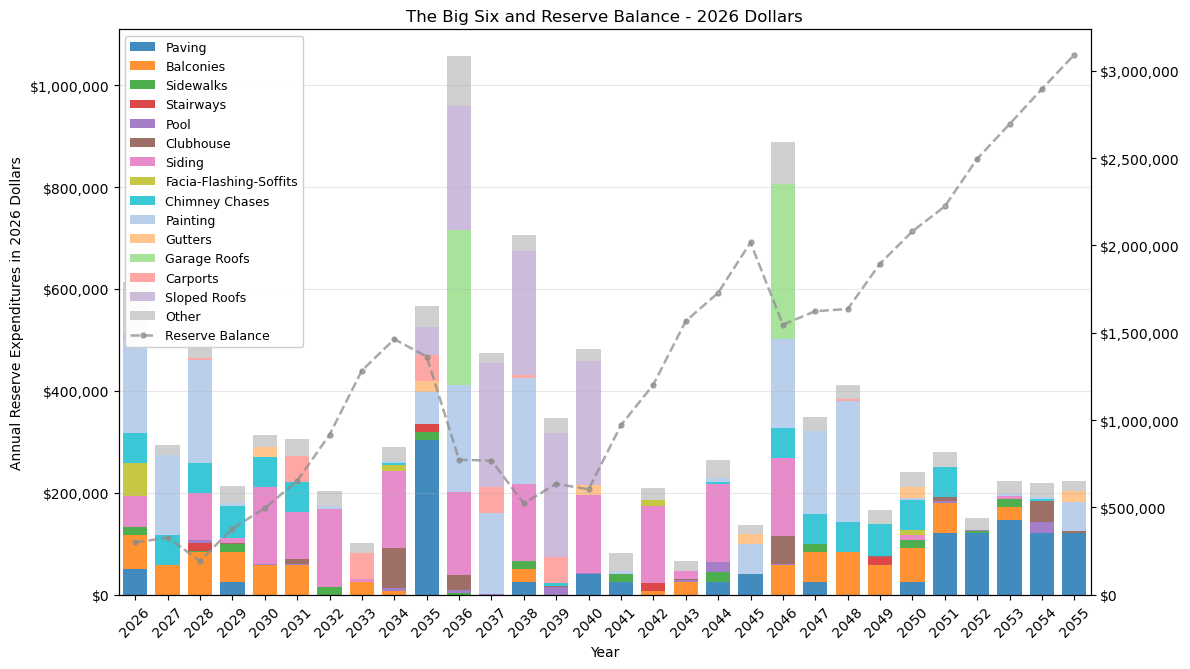

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/maintenance_planning_selected_categories_and_reserve_balance_2026_dollars.pdf')

In [95]:
maintenance_detail = prepare_b6_maintenance_detail(result, plot_df)
planning_years = pd.DataFrame({"year": plot_df["year"].astype(int)})
planning_categories = b6_planning_categories(maintenance_detail)
named_project_categories = planning_categories
category_colors = b6_category_colors(planning_categories)

maintenance_detail["future_cost_2026_dollars"] = maintenance_detail["future_cost"] / (
    (1.0 + inflation) ** (maintenance_detail["year"] - analysis_year)
)

maintenance_by_category = (
    maintenance_detail[maintenance_detail["year"].isin(planning_years["year"])]
    .groupby(["year", "planning_category"], as_index=False)["future_cost_2026_dollars"]
    .sum()
)
maintenance_matrix = (
    maintenance_by_category.pivot_table(
        index="year",
        columns="planning_category",
        values="future_cost_2026_dollars",
        aggfunc="sum",
        fill_value=0.0,
    )
    .reindex(index=planning_years["year"], columns=planning_categories, fill_value=0.0)
    .reset_index()
)
reserve_balance_plot = reserve_projection[["year", "end_balance"]].copy()
reserve_balance_plot["year"] = pd.to_numeric(reserve_balance_plot["year"], errors="coerce").astype(int)
reserve_balance_plot["end_balance"] = pd.to_numeric(
    reserve_balance_plot["end_balance"],
    errors="coerce",
).fillna(0.0)
reserve_balance_plot["end_balance_2026_dollars"] = reserve_balance_plot["end_balance"] / (
    1.03 ** (reserve_balance_plot["year"] - 2026)
)

maintenance_matrix = maintenance_matrix.merge(reserve_balance_plot, on="year", how="left")
maintenance_matrix["end_balance_2026_dollars"] = maintenance_matrix["end_balance_2026_dollars"].fillna(0.0)
fig, ax = plt.subplots(figsize=(12, 6.8))
ax2 = ax.twinx()

bar_bottom = np.zeros(len(maintenance_matrix))
for category in planning_categories:
    values = maintenance_matrix[category].to_numpy(dtype=float)
    ax.bar(
        maintenance_matrix["year"],
        values,
        width=0.75,
        bottom=bar_bottom,
        color=category_colors[category],
        alpha=0.85,
        label=category,
    )
    bar_bottom += values

ax2.plot(
    reserve_balance_plot["year"],
    reserve_balance_plot["end_balance_2026_dollars"],
    color="0.55",
    linestyle="--",
    marker="o",
    markersize=3.5,
    linewidth=1.8,
    alpha=0.75,
    label="Reserve Balance",
)

ax.set_title("The Big Six and Reserve Balance - 2026 Dollars")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Reserve Expenditures in 2026 Dollars")
ax2.set_ylabel("")
ax.set_xticks(maintenance_matrix["year"])
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(maintenance_matrix["year"].min() - 0.5, maintenance_matrix["year"].max() + 0.5)
ax.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.3)

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    fontsize=9,
    frameon=True,
    facecolor="white",
    framealpha=0.95,
    edgecolor="0.8",
)

save_pdf(fig, "maintenance_planning_selected_categories_and_reserve_balance_2026_dollars.pdf")


## The Big Six: Pull-Forward Capacity and Reserve Balance

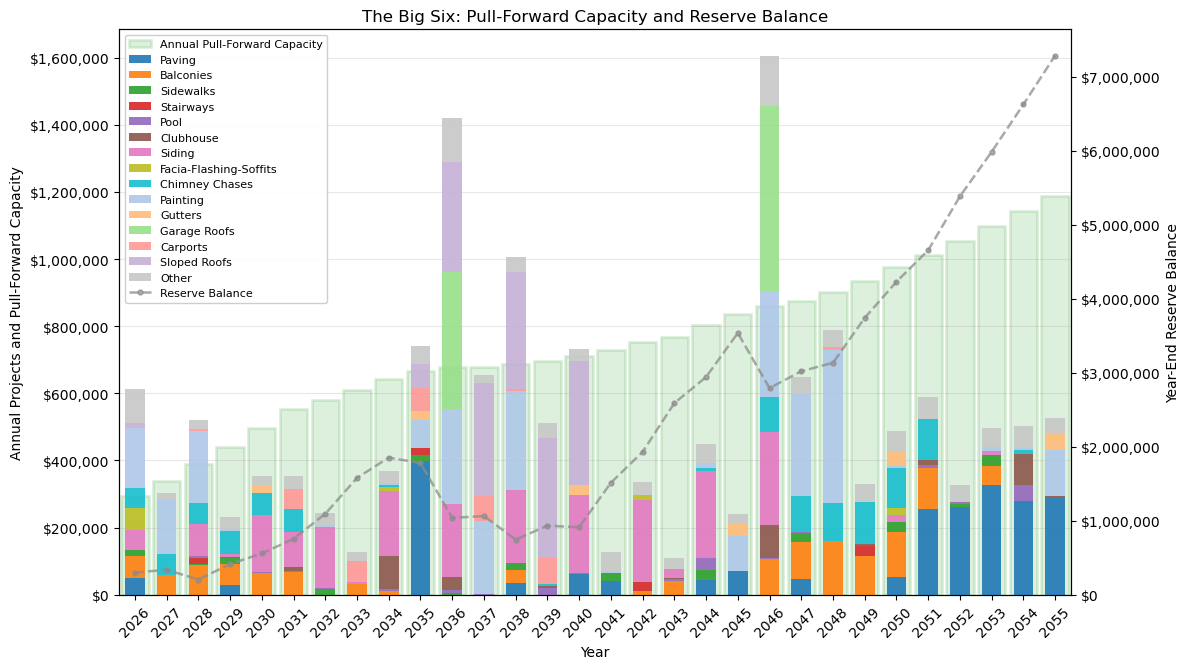

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/maintenance_planning_pull_forward_capacity.pdf')

In [96]:
maintenance_detail = prepare_b6_maintenance_detail(result, plot_df)
planning_years = pd.DataFrame({"year": plot_df["year"].astype(int)})
planning_categories = b6_planning_categories(maintenance_detail)
named_project_categories = planning_categories
category_colors = b6_category_colors(planning_categories)

maintenance_by_category = (
    maintenance_detail[maintenance_detail["year"].isin(planning_years["year"])]
    .groupby(["year", "planning_category"], as_index=False)["future_cost"]
    .sum()
)
maintenance_matrix = (
    maintenance_by_category.pivot_table(
        index="year",
        columns="planning_category",
        values="future_cost",
        aggfunc="sum",
        fill_value=0.0,
    )
    .reindex(index=planning_years["year"], columns=planning_categories, fill_value=0.0)
    .reset_index()
)

reserve_cash_flow = reserve_projection[[
    "year",
    "contribution",
    "special_assessment",
    "additional_income",
    "interest",
    "end_balance",
]].copy()
reserve_cash_flow["year"] = pd.to_numeric(reserve_cash_flow["year"], errors="coerce").astype(int)
for column in ["contribution", "special_assessment", "additional_income", "interest", "end_balance"]:
    reserve_cash_flow[column] = pd.to_numeric(reserve_cash_flow[column], errors="coerce").fillna(0.0)

maintenance_matrix = maintenance_matrix.merge(reserve_cash_flow, on="year", how="left")
for column in ["contribution", "special_assessment", "additional_income", "interest", "end_balance"]:
    maintenance_matrix[column] = maintenance_matrix[column].fillna(0.0)
maintenance_matrix["annual_pull_forward_capacity"] = (
    maintenance_matrix["contribution"]
    + maintenance_matrix["special_assessment"]
    + maintenance_matrix["additional_income"]
    + maintenance_matrix["interest"]
).clip(lower=0.0)

fig, ax = plt.subplots(figsize=(12, 6.8))
ax2 = ax.twinx()

capacity_color = "#2ca02c"
ax.bar(
    maintenance_matrix["year"],
    maintenance_matrix["annual_pull_forward_capacity"],
    width=0.86,
    facecolor=capacity_color,
    edgecolor=capacity_color,
    alpha=0.16,
    linewidth=2.0,
    label="Annual Pull-Forward Capacity",
    zorder=1,
)

bar_bottom = np.zeros(len(maintenance_matrix))
for category in named_project_categories:
    values = maintenance_matrix[category].to_numpy(dtype=float)
    ax.bar(
        maintenance_matrix["year"],
        values,
        width=0.62,
        bottom=bar_bottom,
        color=category_colors[category],
        alpha=0.9,
        label=category,
        zorder=3,
    )
    bar_bottom += values

ax2.plot(
    maintenance_matrix["year"],
    maintenance_matrix["end_balance"],
    color="0.55",
    linestyle="--",
    marker="o",
    markersize=3.5,
    linewidth=1.8,
    alpha=0.75,
    label="Reserve Balance",
    zorder=4,
)

ax.set_title("The Big Six: Pull-Forward Capacity and Reserve Balance")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Projects and Pull-Forward Capacity")
ax2.set_ylabel("Year-End Reserve Balance")
ax.set_xticks(maintenance_matrix["year"])
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(maintenance_matrix["year"].min() - 0.5, maintenance_matrix["year"].max() + 0.5)
ax.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.3)

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    fontsize=8,
    frameon=True,
    facecolor="white",
    framealpha=0.95,
    edgecolor="0.8",
)

save_pdf(fig, "maintenance_planning_pull_forward_capacity.pdf")


## The Big Six: Pull-Forward Capacity and Reserve Balance in 2026 Dollars

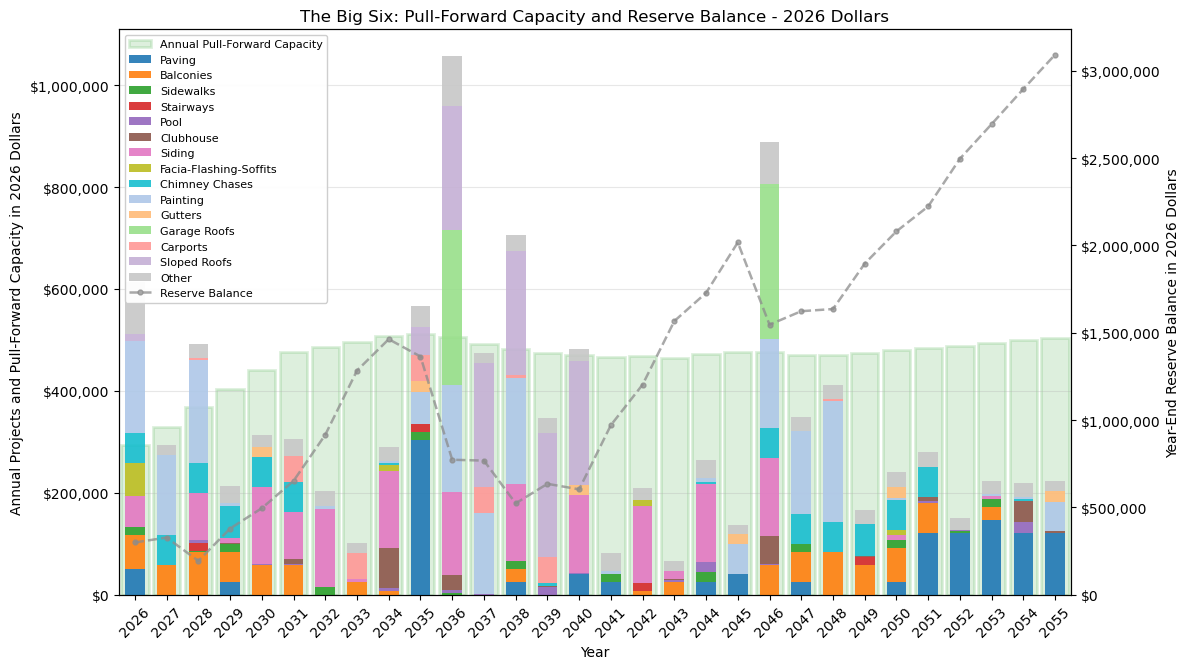

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/maintenance_planning_pull_forward_capacity_2026_dollars.pdf')

In [97]:
maintenance_detail = prepare_b6_maintenance_detail(result, plot_df)
planning_years = pd.DataFrame({"year": plot_df["year"].astype(int)})
planning_categories = b6_planning_categories(maintenance_detail)
named_project_categories = planning_categories
category_colors = b6_category_colors(planning_categories)

maintenance_detail["future_cost_2026_dollars"] = maintenance_detail["future_cost"] / (
    (1.0 + inflation) ** (maintenance_detail["year"] - analysis_year)
)

maintenance_by_category = (
    maintenance_detail[maintenance_detail["year"].isin(planning_years["year"])]
    .groupby(["year", "planning_category"], as_index=False)["future_cost_2026_dollars"]
    .sum()
)
maintenance_matrix = (
    maintenance_by_category.pivot_table(
        index="year",
        columns="planning_category",
        values="future_cost_2026_dollars",
        aggfunc="sum",
        fill_value=0.0,
    )
    .reindex(index=planning_years["year"], columns=planning_categories, fill_value=0.0)
    .reset_index()
)

reserve_cash_flow = reserve_projection[[
    "year",
    "contribution",
    "special_assessment",
    "additional_income",
    "interest",
    "end_balance",
]].copy()
reserve_cash_flow["year"] = pd.to_numeric(reserve_cash_flow["year"], errors="coerce").astype(int)
for column in ["contribution", "special_assessment", "additional_income", "interest", "end_balance"]:
    reserve_cash_flow[column] = pd.to_numeric(reserve_cash_flow[column], errors="coerce").fillna(0.0)
for column in ["contribution", "special_assessment", "additional_income", "interest", "end_balance"]:
    reserve_cash_flow[f"{column}_2026_dollars"] = reserve_cash_flow[column] / (
        1.03 ** (reserve_cash_flow["year"] - 2026)
    )

maintenance_matrix = maintenance_matrix.merge(reserve_cash_flow, on="year", how="left")
for column in ["contribution_2026_dollars", "special_assessment_2026_dollars", "additional_income_2026_dollars", "interest_2026_dollars", "end_balance_2026_dollars"]:
    maintenance_matrix[column] = maintenance_matrix[column].fillna(0.0)
maintenance_matrix["annual_pull_forward_capacity"] = (
    maintenance_matrix["contribution_2026_dollars"]
    + maintenance_matrix["special_assessment_2026_dollars"]
    + maintenance_matrix["additional_income_2026_dollars"]
    + maintenance_matrix["interest_2026_dollars"]
).clip(lower=0.0)

fig, ax = plt.subplots(figsize=(12, 6.8))
ax2 = ax.twinx()

capacity_color = "#2ca02c"
ax.bar(
    maintenance_matrix["year"],
    maintenance_matrix["annual_pull_forward_capacity"],
    width=0.86,
    facecolor=capacity_color,
    edgecolor=capacity_color,
    alpha=0.16,
    linewidth=2.0,
    label="Annual Pull-Forward Capacity",
    zorder=1,
)

bar_bottom = np.zeros(len(maintenance_matrix))
for category in named_project_categories:
    values = maintenance_matrix[category].to_numpy(dtype=float)
    ax.bar(
        maintenance_matrix["year"],
        values,
        width=0.62,
        bottom=bar_bottom,
        color=category_colors[category],
        alpha=0.9,
        label=category,
        zorder=3,
    )
    bar_bottom += values

ax2.plot(
    maintenance_matrix["year"],
    maintenance_matrix["end_balance_2026_dollars"],
    color="0.55",
    linestyle="--",
    marker="o",
    markersize=3.5,
    linewidth=1.8,
    alpha=0.75,
    label="Reserve Balance",
    zorder=4,
)

ax.set_title("The Big Six: Pull-Forward Capacity and Reserve Balance - 2026 Dollars")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Projects and Pull-Forward Capacity in 2026 Dollars")
ax2.set_ylabel("Year-End Reserve Balance in 2026 Dollars")
ax.set_xticks(maintenance_matrix["year"])
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(maintenance_matrix["year"].min() - 0.5, maintenance_matrix["year"].max() + 0.5)
ax.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.3)

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    fontsize=8,
    frameon=True,
    facecolor="white",
    framealpha=0.95,
    edgecolor="0.8",
)

save_pdf(fig, "maintenance_planning_pull_forward_capacity_2026_dollars.pdf")


## The Big Six: Category Share Pie Chart

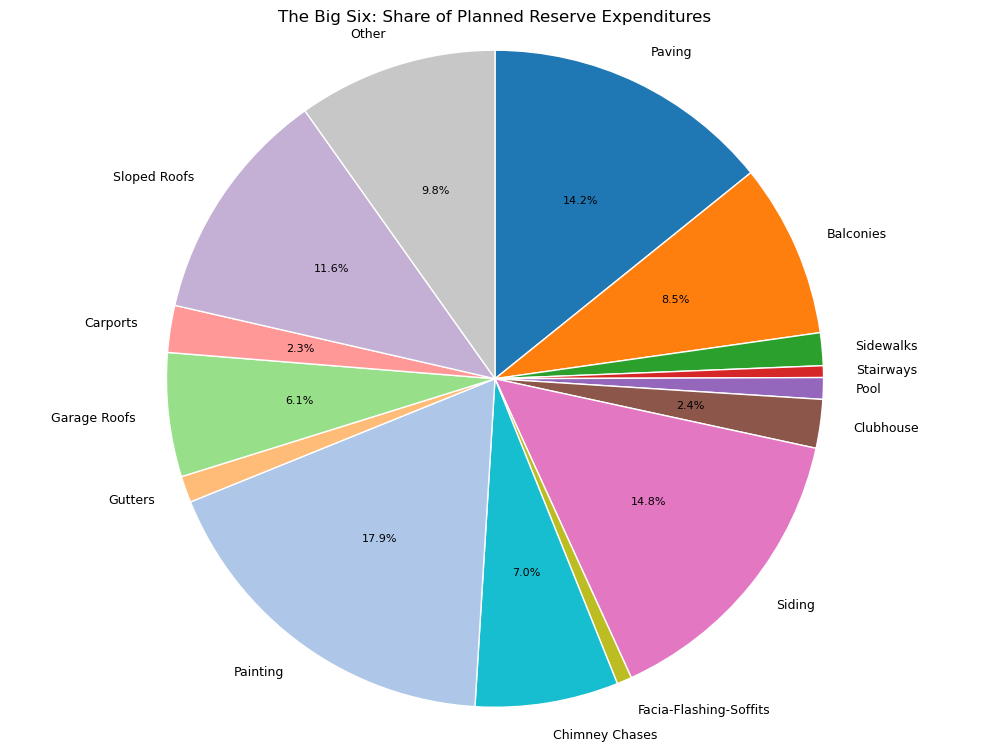

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/maintenance_planning_category_share_pie.pdf')

In [98]:

maintenance_detail = prepare_b6_maintenance_detail(result, plot_df)
planning_years = pd.DataFrame({"year": plot_df["year"].astype(int)})
planning_categories = b6_planning_categories(maintenance_detail)
named_project_categories = planning_categories
category_colors = b6_category_colors(planning_categories)

category_totals = (
    maintenance_detail.groupby("planning_category")["future_cost"]
    .sum()
    .reindex(planning_categories, fill_value=0.0)
)
category_totals = category_totals[category_totals > 0]
colors = [category_colors[category] for category in category_totals.index]

fig, ax = plt.subplots(figsize=(10, 7.5))
wedges, texts, autotexts = ax.pie(
    category_totals,
    labels=category_totals.index,
    colors=colors,
    autopct=lambda pct: f"{pct:.1f}%" if pct >= 2 else "",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white", "linewidth": 1.0},
    textprops={"fontsize": 9},
)
for autotext in autotexts:
    autotext.set_fontsize(8)
    autotext.set_color("black")

ax.set_title("The Big Six: Share of Planned Reserve Expenditures")
ax.axis("equal")

save_pdf(fig, "maintenance_planning_category_share_pie.pdf")


## The Big Six: Category Share Pie Chart in 2026 Dollars

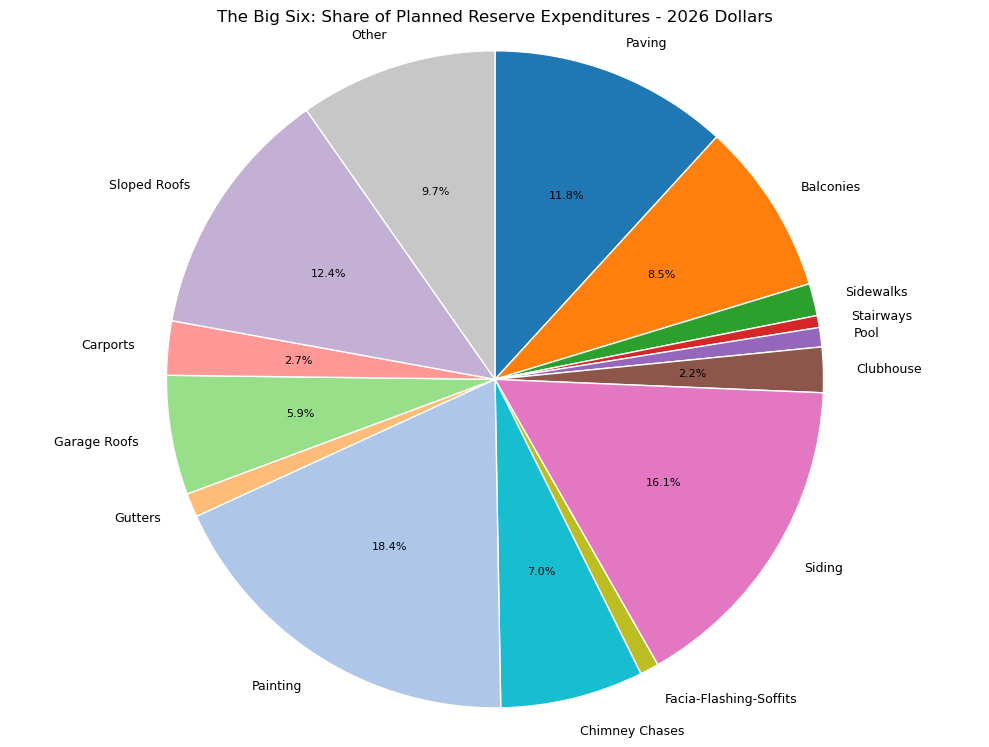

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/maintenance_planning_category_share_pie_2026_dollars.pdf')

In [99]:

maintenance_detail = prepare_b6_maintenance_detail(result, plot_df)
planning_years = pd.DataFrame({"year": plot_df["year"].astype(int)})
planning_categories = b6_planning_categories(maintenance_detail)
named_project_categories = planning_categories
category_colors = b6_category_colors(planning_categories)

maintenance_detail["future_cost_2026_dollars"] = maintenance_detail["future_cost"] / (
    (1.0 + inflation) ** (maintenance_detail["year"] - analysis_year)
)

category_totals = (
    maintenance_detail.groupby("planning_category")["future_cost_2026_dollars"]
    .sum()
    .reindex(planning_categories, fill_value=0.0)
)
category_totals = category_totals[category_totals > 0]
colors = [category_colors[category] for category in category_totals.index]

fig, ax = plt.subplots(figsize=(10, 7.5))
wedges, texts, autotexts = ax.pie(
    category_totals,
    labels=category_totals.index,
    colors=colors,
    autopct=lambda pct: f"{pct:.1f}%" if pct >= 2 else "",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white", "linewidth": 1.0},
    textprops={"fontsize": 9},
)
for autotext in autotexts:
    autotext.set_fontsize(8)
    autotext.set_color("black")

ax.set_title("The Big Six: Share of Planned Reserve Expenditures - 2026 Dollars")
ax.axis("equal")

save_pdf(fig, "maintenance_planning_category_share_pie_2026_dollars.pdf")


## Reserve Balance

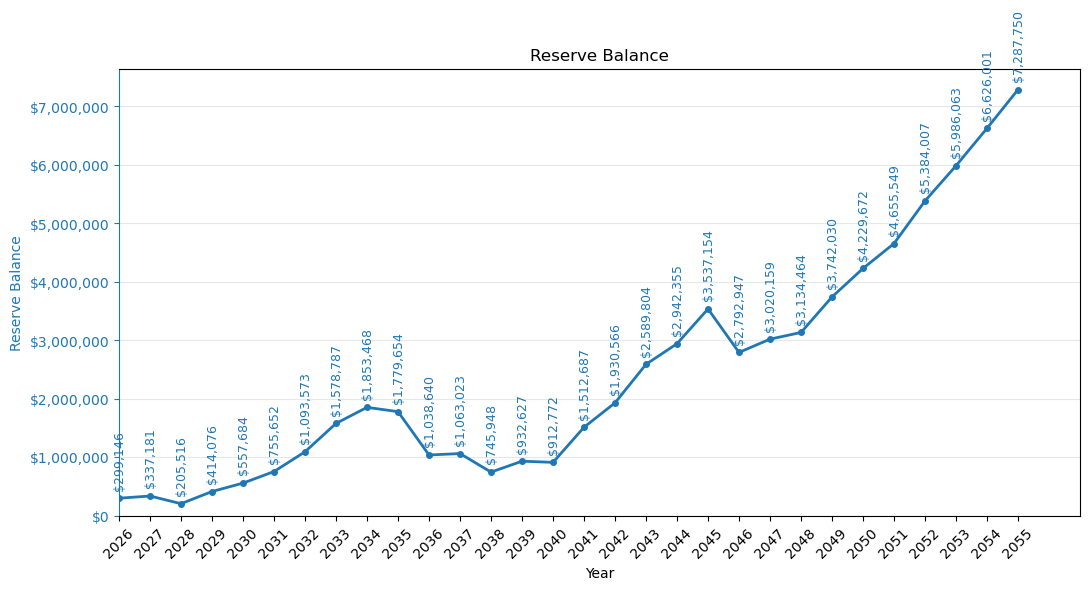

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/reserve_balance.pdf')

In [100]:
proj = reserve_projection.copy()
proj["year"] = pd.to_numeric(proj["year"], errors="coerce")
proj["end_balance"] = pd.to_numeric(proj["end_balance"], errors="coerce")
proj = proj.dropna(subset=["year", "end_balance"]).copy()
proj["year"] = proj["year"].astype(int)
proj = proj.sort_values("year").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 6))
balance_color = plt.rcParams["axes.prop_cycle"].by_key()["color"][0]

ax.plot(proj["year"], proj["end_balance"], marker="o", markersize=4, linewidth=2.0, linestyle="-", color=balance_color)
ax.set_title("Reserve Balance")
ax.set_xlabel("Year")
ax.set_ylabel("Reserve Balance", color=balance_color)
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", colors=balance_color)
ax.spines["left"].set_color(balance_color)
ax.yaxis.label.set_color(balance_color)
ax.set_xticks(proj["year"])
ax.set_xlim(proj["year"].min(), proj["year"].max() + 2)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.3)

for _, row in proj.iterrows():
    ax.annotate(
        f'${row["end_balance"]:,.0f}',
        xy=(row["year"], row["end_balance"]),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9,
        color=balance_color,
    )

save_pdf(fig, "reserve_balance.pdf")

## Contributions Detail

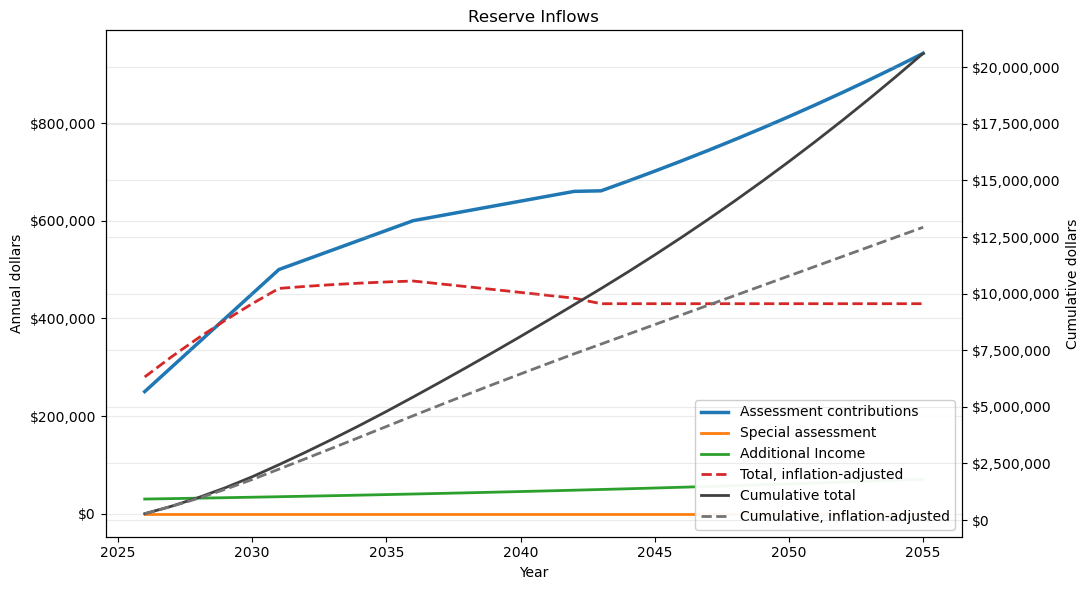

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/contributions_detail.pdf')

In [101]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(plot_df["year"], plot_df["annual_contribution"], linewidth=2.5, label="Assessment contributions")
ax.plot(plot_df["year"], plot_df["special_assessment"], linewidth=2.0, label="Special assessment")
ax.plot(plot_df["year"], plot_df["additional_income"], linewidth=2.0, label="Additional Income")
ax.plot(plot_df["year"], plot_df["total_contributions_real"], linewidth=2.0, linestyle="--", label="Total, inflation-adjusted")

ax2 = ax.twinx()
ax2.plot(plot_df["year"], plot_df["cumulative_contributions"], color="0.25", linewidth=2.0, label="Cumulative total")
ax2.plot(plot_df["year"], plot_df["cumulative_contributions_real"], color="0.45", linewidth=2.0, linestyle="--", label="Cumulative, inflation-adjusted")

ax.set_title("Reserve Inflows")
ax.set_xlabel("Year")
ax.set_ylabel("Annual dollars")
ax2.set_ylabel("Cumulative dollars")
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.25)
ax2.grid(True, axis="y", alpha=0.25)

lines = ax.get_lines() + ax2.get_lines()
ax.legend(lines, [line.get_label() for line in lines], loc="lower right", frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.8")

save_pdf(fig, "contributions_detail.pdf")

## Expenditures vs. Contributions Detail

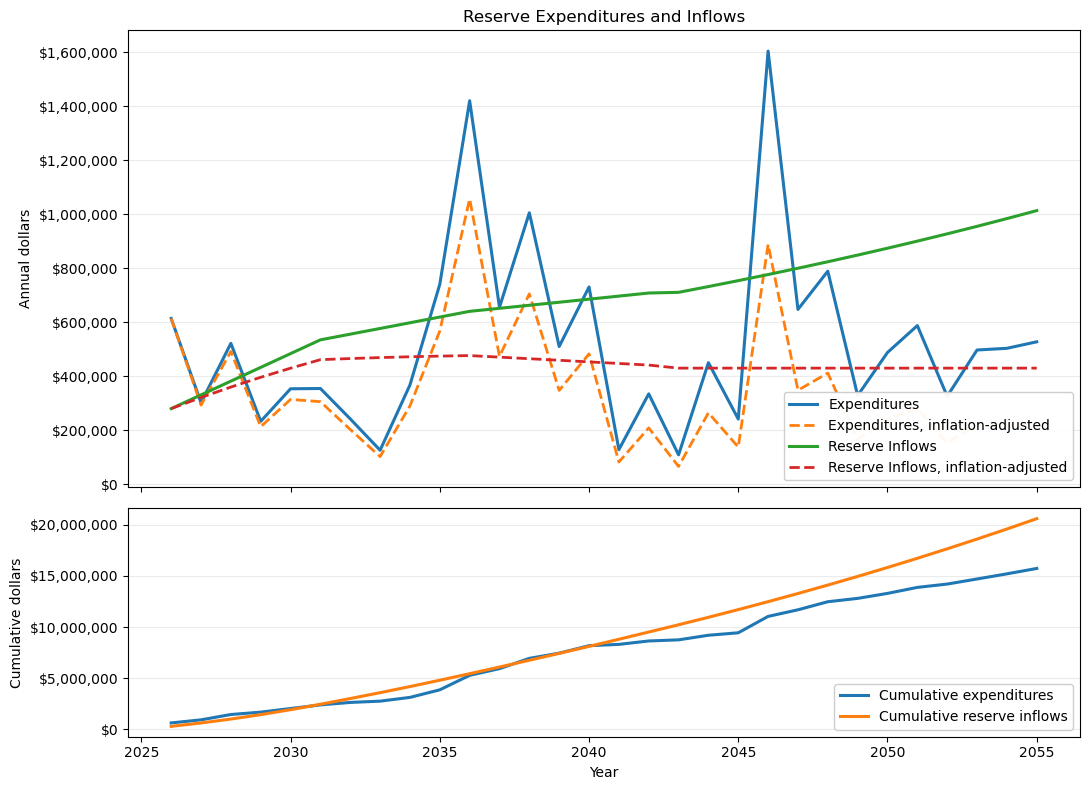

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/expenditures_vs_contributions_detail.pdf')

In [102]:
fig, (ax, ax_bottom) = plt.subplots(
    2,
    1,
    figsize=(11, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

ax.plot(plot_df["year"], plot_df["expenditures"], linewidth=2.2, label="Expenditures")
ax.plot(plot_df["year"], plot_df["expenditures_real"], linewidth=2.0, linestyle="--", label="Expenditures, inflation-adjusted")
ax.plot(plot_df["year"], plot_df["total_contributions"], linewidth=2.2, label="Reserve Inflows")
ax.plot(plot_df["year"], plot_df["total_contributions_real"], linewidth=2.0, linestyle="--", label="Reserve Inflows, inflation-adjusted")

ax_bottom.plot(plot_df["year"], plot_df["cumulative_expenditures"], linewidth=2.2, label="Cumulative expenditures")
ax_bottom.plot(plot_df["year"], plot_df["cumulative_contributions"], linewidth=2.2, label="Cumulative reserve inflows")

ax.set_title("Reserve Expenditures and Inflows")
ax.set_ylabel("Annual dollars")
ax_bottom.set_xlabel("Year")
ax_bottom.set_ylabel("Cumulative dollars")
ax.yaxis.set_major_formatter(money_formatter)
ax_bottom.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.25)
ax_bottom.grid(True, axis="y", alpha=0.25)
ax.legend(loc="lower right", frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.8")
ax_bottom.legend(loc="lower right", frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.8")

save_pdf(fig, "expenditures_vs_contributions_detail.pdf")

## Reserve Balance vs. Fully Funded

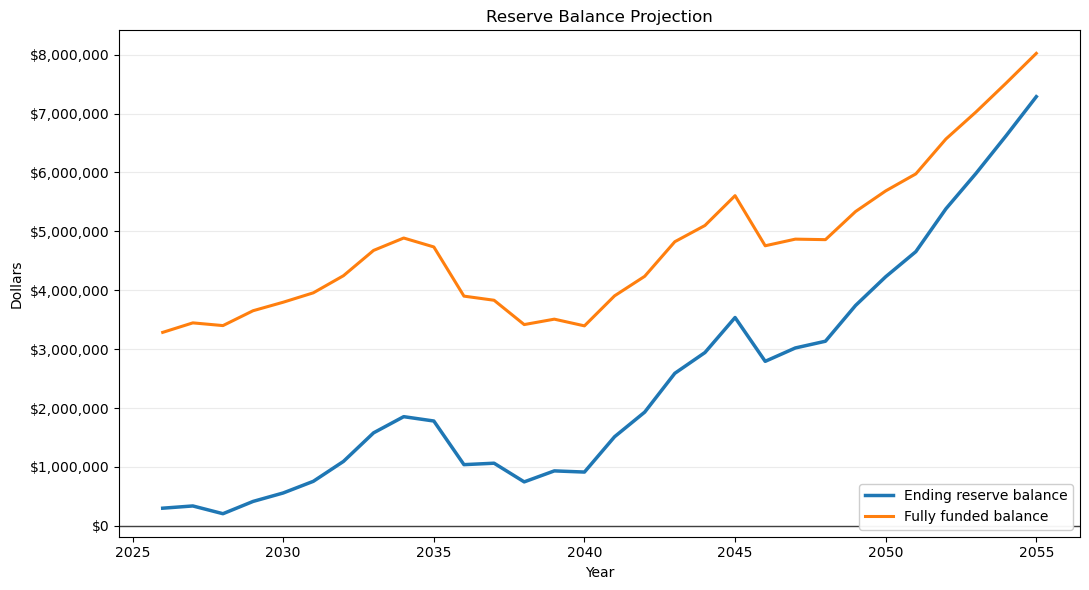

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/reserve_balance_vs_fully_funded.pdf')

In [103]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(reserve_projection["year"], reserve_projection["end_balance"], linewidth=2.5, label="Ending reserve balance")
if "funded_balance" in reserve_projection:
    ax.plot(reserve_projection["year"], reserve_projection["funded_balance"], linewidth=2.2, label="Fully funded balance")

ax.axhline(0, color="0.25", linewidth=1)
ax.set_title("Reserve Balance Projection")
ax.set_xlabel("Year")
ax.set_ylabel("Dollars")
ax.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.25)
ax.legend(loc="lower right", frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.8")

save_pdf(fig, "reserve_balance_vs_fully_funded.pdf")

## Percent Funded

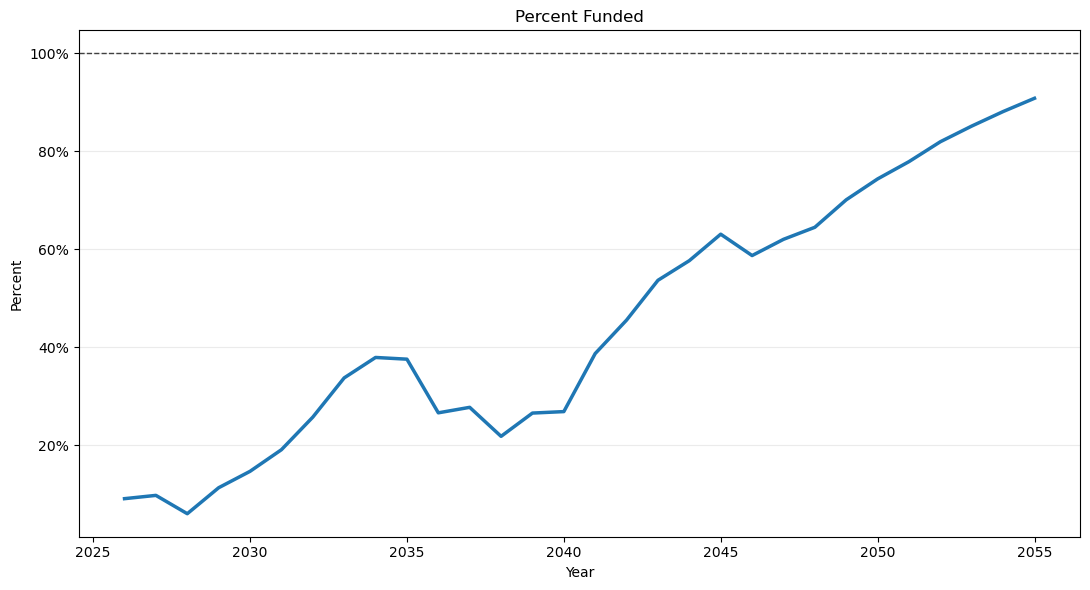

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/percent_funded.pdf')

In [104]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(reserve_projection["year"], reserve_projection["percent_funded"], linewidth=2.5)
ax.axhline(100, color="0.25", linewidth=1, linestyle="--")
ax.set_title("Percent Funded")
ax.set_xlabel("Year")
ax.set_ylabel("Percent")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(True, axis="y", alpha=0.25)

save_pdf(fig, "percent_funded.pdf")

## Board Communication Plot Prep


In [105]:
board_maintenance_detail = prepare_b6_maintenance_detail(result, plot_df)
board_planning_categories = b6_planning_categories(board_maintenance_detail)
board_category_colors = b6_category_colors(board_planning_categories)

board_years = pd.DataFrame({"year": plot_df["year"].astype(int)})
board_maintenance_detail["future_cost_2026_dollars"] = board_maintenance_detail["future_cost"] / (
    (1.0 + inflation) ** (board_maintenance_detail["year"] - analysis_year)
)

board_maintenance_by_category = (
    board_maintenance_detail.groupby(["year", "planning_category"], as_index=False)["future_cost"]
    .sum()
)
board_maintenance_matrix_nominal = (
    board_maintenance_by_category.pivot_table(
        index="year",
        columns="planning_category",
        values="future_cost",
        aggfunc="sum",
        fill_value=0.0,
    )
    .reindex(index=board_years["year"], columns=board_planning_categories, fill_value=0.0)
    .reset_index()
)
board_maintenance_matrix_nominal["total_projects"] = board_maintenance_matrix_nominal[
    board_planning_categories
].sum(axis=1)

board_maintenance_by_category_real = (
    board_maintenance_detail.groupby(["year", "planning_category"], as_index=False)["future_cost_2026_dollars"]
    .sum()
)
board_maintenance_matrix_real = (
    board_maintenance_by_category_real.pivot_table(
        index="year",
        columns="planning_category",
        values="future_cost_2026_dollars",
        aggfunc="sum",
        fill_value=0.0,
    )
    .reindex(index=board_years["year"], columns=board_planning_categories, fill_value=0.0)
    .reset_index()
)
board_maintenance_matrix_real["total_projects"] = board_maintenance_matrix_real[
    board_planning_categories
].sum(axis=1)

board_cash_flow = reserve_projection[[
    "year",
    "begin_balance",
    "contribution",
    "special_assessment",
    "additional_income",
    "expenditures",
    "interest",
    "end_balance",
    "funded_balance",
    "percent_funded",
]].copy()
board_cash_flow["year"] = pd.to_numeric(board_cash_flow["year"], errors="coerce").astype(int)
for column in [
    "begin_balance",
    "contribution",
    "special_assessment",
    "additional_income",
    "expenditures",
    "interest",
    "end_balance",
    "funded_balance",
    "percent_funded",
]:
    board_cash_flow[column] = pd.to_numeric(board_cash_flow[column], errors="coerce").fillna(0.0)
board_cash_flow["total_contribution"] = board_cash_flow["contribution"] + board_cash_flow["special_assessment"] + board_cash_flow["additional_income"]
board_cash_flow["inflation_factor_to_2026"] = (1.0 + inflation) ** (board_cash_flow["year"] - analysis_year)
for column in ["begin_balance", "contribution", "special_assessment", "additional_income", "expenditures", "interest", "end_balance", "funded_balance", "total_contribution"]:
    board_cash_flow[f"{column}_2026_dollars"] = board_cash_flow[column] / board_cash_flow["inflation_factor_to_2026"]

board_category_totals_nominal = (
    board_maintenance_detail.groupby("planning_category")["future_cost"]
    .sum()
    .reindex(board_planning_categories, fill_value=0.0)
)
board_category_totals_real = (
    board_maintenance_detail.groupby("planning_category")["future_cost_2026_dollars"]
    .sum()
    .reindex(board_planning_categories, fill_value=0.0)
)

units_raw = result.scenario.association_properties.get("NUM_UNITS", "138")
unit_count = int(float(units_raw))
board_monthly = board_cash_flow[["year", "contribution", "additional_income", "total_contribution"]].copy()
board_monthly["reserve_per_unit_per_month"] = board_monthly["contribution"] / unit_count / 12.0
board_monthly["additional_income_per_unit_per_month"] = board_monthly["additional_income"] / unit_count / 12.0
board_monthly["total_reserve_collections_per_unit_per_month"] = board_monthly["total_contribution"] / unit_count / 12.0

board_maintenance_matrix_nominal.head()


planning_category,year,Paving,Balconies,Sidewalks,Stairways,Pool,Clubhouse,Siding,Facia-Flashing-Soffits,Chimney Chases,Painting,Gutters,Garage Roofs,Carports,Sloped Roofs,Other,total_projects
0,2026,50744.46,65967.80,15223.34,0.00,0.00,0.00,60893.35,65967.79,58356.13,180057.57,0.00,0.0,0.00,15223.34,101498.04,613931.82
1,2027,0.00,60106.81,0.00,0.00,0.00,0.00,0.00,0.00,60106.81,162758.79,0.00,0.0,0.00,0.00,18816.05,301788.46
2,2028,0.00,88827.41,3230.09,16150.44,6330.97,0.00,96902.63,0.00,61910.01,214503.67,0.00,0.0,5383.48,0.00,28532.44,521771.14
3,2029,27724.92,63767.32,16634.95,0.00,0.00,2772.49,11089.97,0.00,69312.30,5544.98,0.00,0.0,0.00,0.00,36042.39,232889.32
4,2030,0.00,65680.33,0.00,0.00,1713.40,0.00,171340.00,0.00,65680.33,0.00,22845.33,0.0,0.00,0.00,26272.13,353531.52


## Reserve Balance Cushion Plot


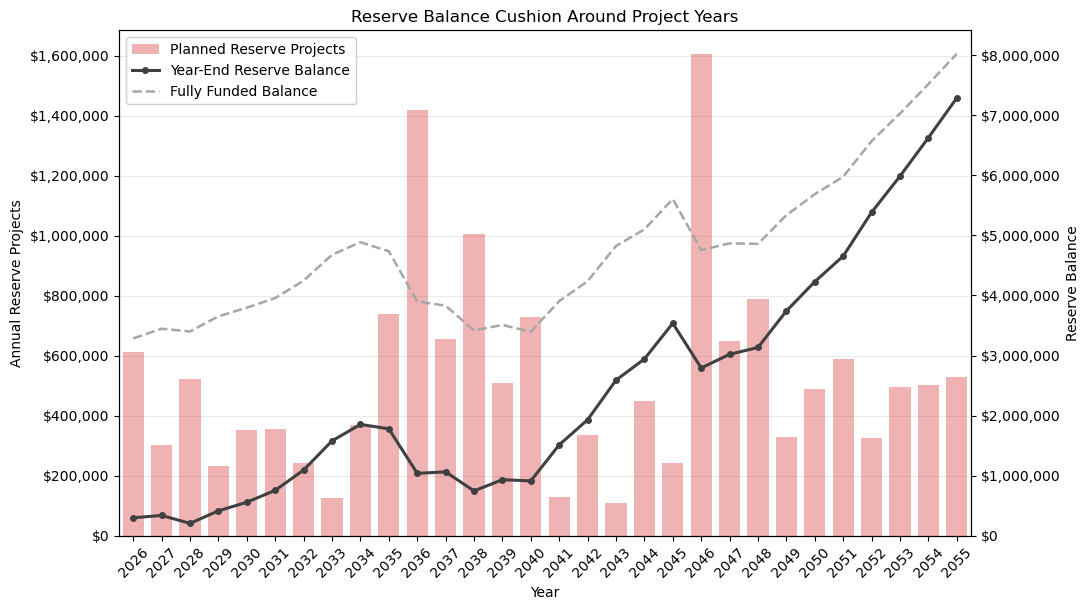

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/reserve_balance_cushion_around_project_years.pdf')

In [106]:
fig, ax = plt.subplots(figsize=(11, 6.2))
ax2 = ax.twinx()

ax.bar(
    board_maintenance_matrix_nominal["year"],
    board_maintenance_matrix_nominal["total_projects"],
    width=0.75,
    color="#d62728",
    alpha=0.35,
    label="Planned Reserve Projects",
    zorder=2,
)
ax2.plot(
    board_cash_flow["year"],
    board_cash_flow["end_balance"],
    color="0.25",
    marker="o",
    markersize=4,
    linewidth=2.2,
    label="Year-End Reserve Balance",
    zorder=4,
)
ax2.plot(
    board_cash_flow["year"],
    board_cash_flow["funded_balance"],
    color="0.65",
    linestyle="--",
    linewidth=1.8,
    label="Fully Funded Balance",
    zorder=3,
)

ax.set_title("Reserve Balance Cushion Around Project Years")
ax.set_xlabel("Year")
ax.set_ylabel("Annual Reserve Projects")
ax2.set_ylabel("Reserve Balance")
ax.set_xticks(board_cash_flow["year"])
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(board_cash_flow["year"].min() - 0.5, board_cash_flow["year"].max() + 0.5)
ax.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.25)

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    frameon=True,
    facecolor="white",
    framealpha=0.95,
    edgecolor="0.8",
)

save_pdf(fig, "reserve_balance_cushion_around_project_years.pdf")


## Project Pull-Forward Feasibility Plot


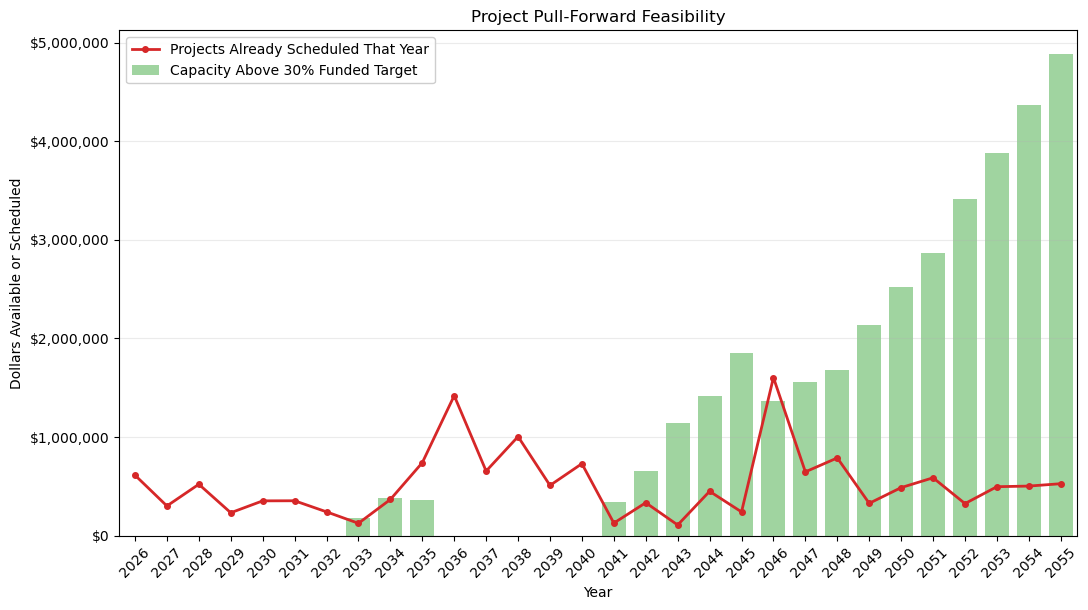

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/project_pull_forward_feasibility.pdf')

In [107]:
pull_forward = board_cash_flow.merge(
    board_maintenance_matrix_nominal[["year", "total_projects"]],
    on="year",
    how="left",
)
pull_forward["total_projects"] = pull_forward["total_projects"].fillna(0.0)
pull_forward["target_minimum_balance"] = 0.30 * pull_forward["funded_balance"]
pull_forward["available_after_target"] = (
    pull_forward["end_balance"] - pull_forward["target_minimum_balance"]
).clip(lower=0.0)

fig, ax = plt.subplots(figsize=(11, 6.2))

ax.bar(
    pull_forward["year"],
    pull_forward["available_after_target"],
    width=0.75,
    color="#2ca02c",
    alpha=0.45,
    label="Capacity Above 30% Funded Target",
)
ax.plot(
    pull_forward["year"],
    pull_forward["total_projects"],
    color="#d62728",
    marker="o",
    markersize=4,
    linewidth=2.0,
    label="Projects Already Scheduled That Year",
)

ax.set_title("Project Pull-Forward Feasibility")
ax.set_xlabel("Year")
ax.set_ylabel("Dollars Available or Scheduled")
ax.set_xticks(pull_forward["year"])
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(pull_forward["year"].min() - 0.5, pull_forward["year"].max() + 0.5)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.25)
ax.legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    framealpha=0.95,
    edgecolor="0.8",
)

save_pdf(fig, "project_pull_forward_feasibility.pdf")


## Risk of a Special Assessment


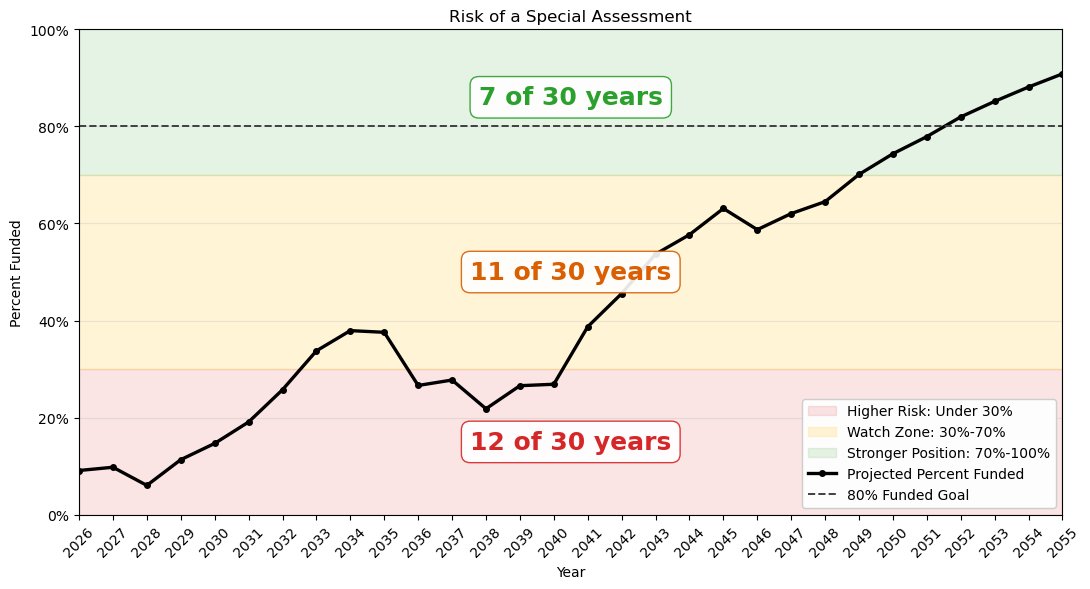

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/percent_funded_risk_bands.pdf')

In [108]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.axhspan(0, 30, color="#d62728", alpha=0.12, label="Higher Risk: Under 30%")
ax.axhspan(30, 70, color="#ffbf00", alpha=0.16, label="Watch Zone: 30%-70%")
ax.axhspan(70, 100, color="#2ca02c", alpha=0.12, label="Stronger Position: 70%-100%")
ax.plot(
    board_cash_flow["year"],
    board_cash_flow["percent_funded"],
    color="black",
    marker="o",
    markersize=4,
    linewidth=2.4,
    label="Projected Percent Funded",
)
ax.axhline(80, color="0.25", linestyle="--", linewidth=1.4, label="80% Funded Goal")

ax.set_title("Risk of a Special Assessment")
ax.set_xlabel("Year")
ax.set_ylabel("Percent Funded")
ax.set_xticks(board_cash_flow["year"])
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(board_cash_flow["year"].min(), board_cash_flow["year"].max())
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(True, axis="y", alpha=0.25)

projection_year_count = len(board_cash_flow)
risk_band_counts = [
    {
        "label": "Higher Risk",
        "count": int((board_cash_flow["percent_funded"] < 30).sum()),
        "y": 15,
        "color": "#d62728",
    },
    {
        "label": "Watch Zone",
        "count": int(board_cash_flow["percent_funded"].between(30, 70, inclusive="left").sum()),
        "y": 50,
        "color": "#d95f02",
    },
    {
        "label": "Stronger Position",
        "count": int((board_cash_flow["percent_funded"] >= 70).sum()),
        "y": 86,
        "color": "#2ca02c",
    },
]
band_text_x = board_cash_flow["year"].min() + (board_cash_flow["year"].max() - board_cash_flow["year"].min()) * 0.50
for band in risk_band_counts:
    ax.text(
        band_text_x,
        band["y"],
        f"{band['count']} of {projection_year_count} years",
        color=band["color"],
        fontsize=18,
        fontweight="bold",
        ha="center",
        va="center",
        bbox={"facecolor": "white", "edgecolor": band["color"], "alpha": 0.9, "boxstyle": "round,pad=0.35"},
    )

ax.legend(
    loc="lower right",
    frameon=True,
    facecolor="white",
    framealpha=0.95,
    edgecolor="0.8",
)

save_pdf(fig, "percent_funded_risk_bands.pdf")





## The Big Six Timeline


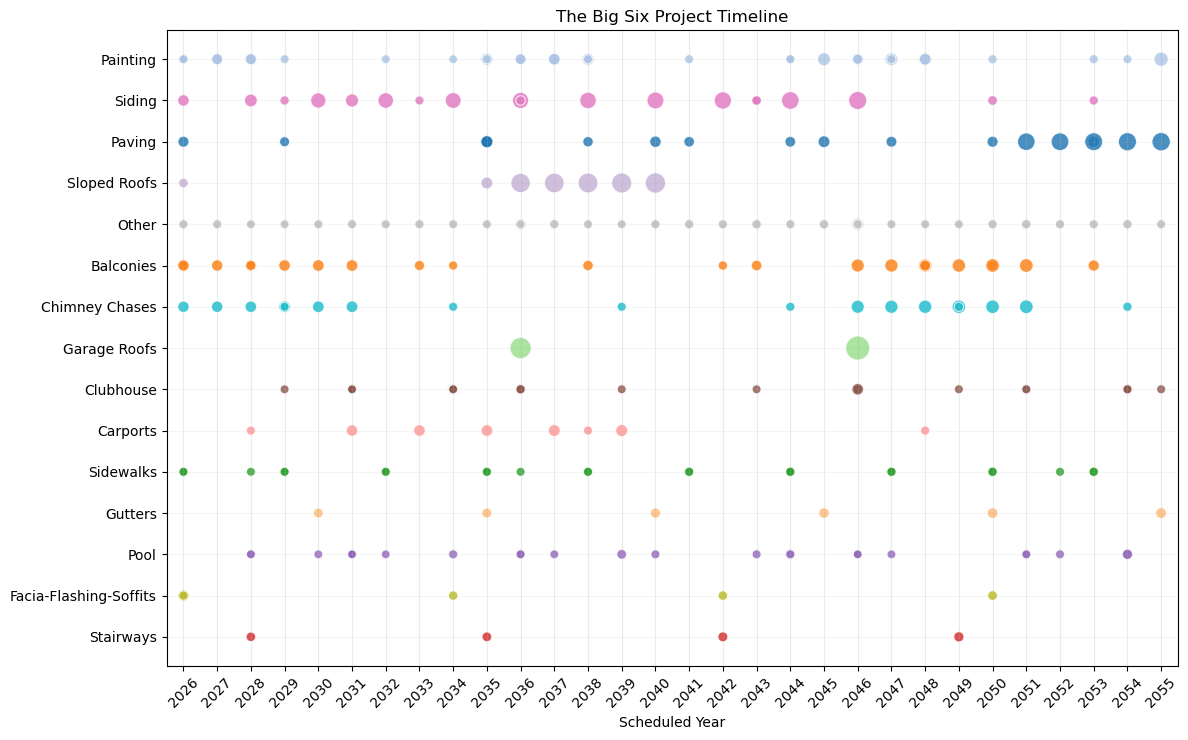

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/big_six_project_timeline.pdf')

In [109]:
timeline_detail = board_maintenance_detail[board_maintenance_detail["future_cost"] > 0].copy()

timeline_category_order = (
    timeline_detail.groupby("planning_category")["future_cost"]
    .sum()
    .sort_values(ascending=False)
    .index
    .tolist()
)
timeline_detail["category_order"] = timeline_detail["planning_category"].map(
    {category: index for index, category in enumerate(timeline_category_order)}
)
timeline_detail = timeline_detail.dropna(subset=["category_order"]).copy()
timeline_detail["marker_size"] = 40 + 260 * (
    timeline_detail["future_cost"] / timeline_detail["future_cost"].max()
)

fig, ax = plt.subplots(figsize=(12, 7.5))

for category in timeline_category_order:
    category_projects = timeline_detail[timeline_detail["planning_category"] == category]
    if category_projects.empty:
        continue
    y = timeline_category_order.index(category)
    ax.scatter(
        category_projects["year"],
        np.full(len(category_projects), y),
        s=category_projects["marker_size"],
        color=board_category_colors[category],
        alpha=0.82,
        edgecolor="white",
        linewidth=0.8,
        label=category,
    )

ax.set_title("The Big Six Project Timeline")
ax.set_xlabel("Scheduled Year")
ax.set_ylabel("")
ax.set_yticks(range(len(timeline_category_order)))
ax.set_yticklabels(timeline_category_order)
ax.set_xticks(board_cash_flow["year"])
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(board_cash_flow["year"].min() - 0.5, board_cash_flow["year"].max() + 0.5)
ax.invert_yaxis()
ax.grid(True, axis="x", alpha=0.25)
ax.grid(True, axis="y", alpha=0.12)

save_pdf(fig, "big_six_project_timeline.pdf")


## Contribution vs. Need Gap Plot


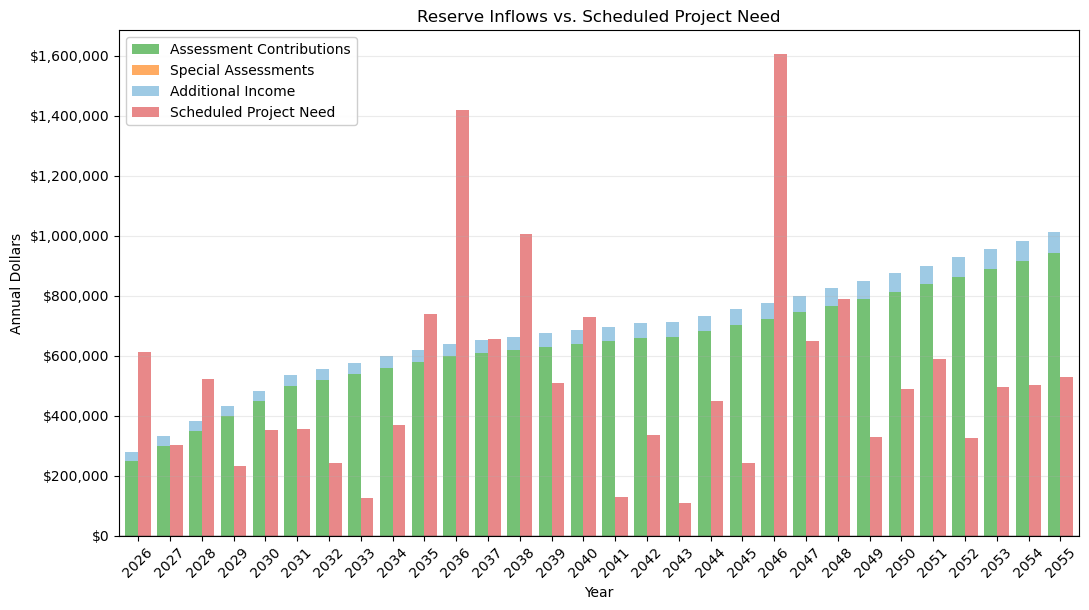

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/contribution_vs_scheduled_project_need.pdf')

In [110]:
need_gap = board_cash_flow.merge(board_maintenance_matrix_nominal[["year", "total_projects"]], on="year", how="left")
need_gap["total_projects"] = need_gap["total_projects"].fillna(0.0)
need_gap["contribution_gap"] = need_gap["total_contribution"] - need_gap["total_projects"]
fig, ax = plt.subplots(figsize=(11, 6.2))
bar_bottom = np.zeros(len(need_gap))
for column, label, color in [("contribution", "Assessment Contributions", "#2ca02c"), ("special_assessment", "Special Assessments", "#ff7f0e"), ("additional_income", "Additional Income", "#6baed6")]:
    ax.bar(need_gap["year"] - 0.2, need_gap[column], width=0.4, bottom=bar_bottom, color=color, alpha=0.65, label=label)
    bar_bottom += need_gap[column].to_numpy(dtype=float)
ax.bar(need_gap["year"] + 0.2, need_gap["total_projects"], width=0.4, color="#d62728", alpha=0.55, label="Scheduled Project Need")
ax.axhline(0, color="0.25", linewidth=1.0)
ax.set_title("Reserve Inflows vs. Scheduled Project Need")
ax.set_xlabel("Year"); ax.set_ylabel("Annual Dollars"); ax.set_xticks(need_gap["year"]); ax.tick_params(axis="x", rotation=45)
ax.set_xlim(need_gap["year"].min() - 0.6, need_gap["year"].max() + 0.6); ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(money_formatter); ax.grid(True, axis="y", alpha=0.25)
ax.legend(loc="upper left", frameon=True, facecolor="white", framealpha=0.95, edgecolor="0.8")
save_pdf(fig, "contribution_vs_scheduled_project_need.pdf")


## Cumulative Deferred Maintenance Catch-Up Plot


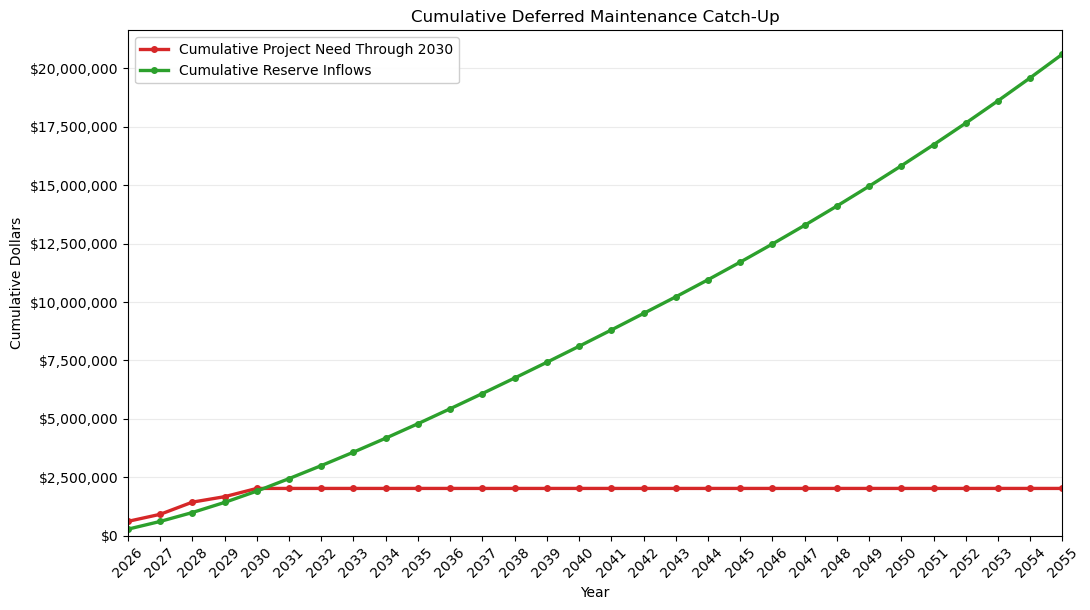

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/cumulative_deferred_maintenance_catch_up.pdf')

In [111]:
deferred_window_end = analysis_year + 4
deferred_catch_up = board_cash_flow.merge(
    board_maintenance_matrix_nominal[["year", "total_projects"]],
    on="year",
    how="left",
)
deferred_catch_up["total_projects"] = deferred_catch_up["total_projects"].fillna(0.0)
deferred_catch_up["near_term_project_need"] = np.where(
    deferred_catch_up["year"] <= deferred_window_end,
    deferred_catch_up["total_projects"],
    0.0,
)
deferred_catch_up["cumulative_near_term_need"] = deferred_catch_up["near_term_project_need"].cumsum()
deferred_catch_up["cumulative_reserve_contributions"] = deferred_catch_up["total_contribution"].cumsum()

fig, ax = plt.subplots(figsize=(11, 6.2))

ax.plot(
    deferred_catch_up["year"],
    deferred_catch_up["cumulative_near_term_need"],
    color="#d62728",
    marker="o",
    markersize=4,
    linewidth=2.4,
    label=f"Cumulative Project Need Through {deferred_window_end}",
)
ax.plot(
    deferred_catch_up["year"],
    deferred_catch_up["cumulative_reserve_contributions"],
    color="#2ca02c",
    marker="o",
    markersize=4,
    linewidth=2.4,
    label="Cumulative Reserve Inflows",
)

ax.set_title("Cumulative Deferred Maintenance Catch-Up")
ax.set_xlabel("Year")
ax.set_ylabel("Cumulative Dollars")
ax.set_xticks(deferred_catch_up["year"])
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(deferred_catch_up["year"].min(), deferred_catch_up["year"].max())
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.25)
ax.legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    framealpha=0.95,
    edgecolor="0.8",
)

save_pdf(fig, "cumulative_deferred_maintenance_catch_up.pdf")


## Per-Unit Monthly Impact Plot


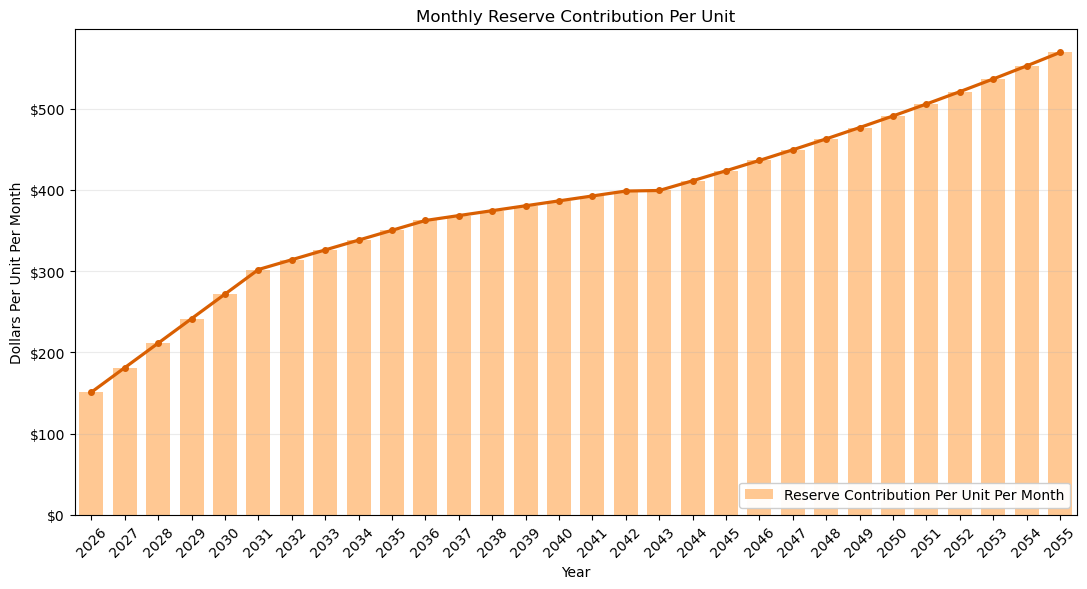

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/monthly_reserve_contribution_per_unit.pdf')

In [112]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(
    board_monthly["year"],
    board_monthly["reserve_per_unit_per_month"],
    width=0.72,
    color="#ffbb78",
    alpha=0.8,
    label="Reserve Contribution Per Unit Per Month",
)
ax.plot(
    board_monthly["year"],
    board_monthly["reserve_per_unit_per_month"],
    color="#d95f02",
    marker="o",
    markersize=4,
    linewidth=2.3,
)

ax.set_title("Monthly Reserve Contribution Per Unit")
ax.set_xlabel("Year")
ax.set_ylabel("Dollars Per Unit Per Month")
ax.set_xticks(board_monthly["year"])
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(board_monthly["year"].min() - 0.5, board_monthly["year"].max() + 0.5)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(money_formatter)
ax.grid(True, axis="y", alpha=0.25)
ax.legend(
    loc="lower right",
    frameon=True,
    facecolor="white",
    framealpha=0.95,
    edgecolor="0.8",
)

save_pdf(fig, "monthly_reserve_contribution_per_unit.pdf")


## Scenario Comparison Plot


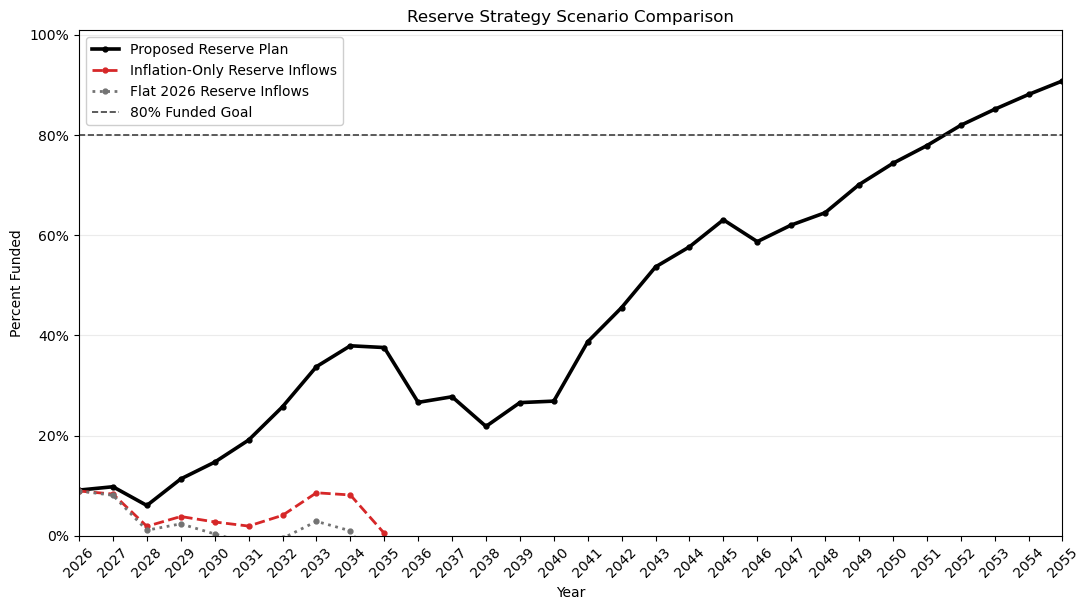

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/reserve_strategy_scenario_comparison.pdf')

In [113]:
def simulate_reserve_balance(contribution_series, label):
    investment_rate = float(result.scenario.assumptions.investment)
    simulated_rows = []
    balance = float(board_cash_flow["begin_balance"].iloc[0])
    for _, row in board_cash_flow.iterrows():
        year = int(row["year"])
        contribution = float(contribution_series.loc[year])
        expenditures = float(row["expenditures"])
        interest = max(balance + contribution - expenditures, 0.0) * investment_rate
        end_balance = balance + contribution - expenditures + interest
        funded_balance = float(row["funded_balance"])
        percent_funded = 0.0 if funded_balance == 0 else end_balance / funded_balance * 100.0
        simulated_rows.append({
            "year": year,
            "scenario": label,
            "end_balance": end_balance,
            "percent_funded": percent_funded,
        })
        balance = end_balance
    return pd.DataFrame(simulated_rows)

scenario_years = board_cash_flow["year"].astype(int)
actual_contributions = board_cash_flow.set_index("year")["total_contribution"]
inflation_only_contributions = pd.Series(
    actual_contributions.iloc[0] * ((1.0 + inflation) ** (scenario_years - analysis_year)).to_numpy(),
    index=scenario_years,
)
flat_contributions = pd.Series(
    actual_contributions.iloc[0],
    index=scenario_years,
)

scenario_comparison = pd.concat([
    board_cash_flow[["year", "end_balance", "percent_funded"]].assign(scenario="Proposed Reserve Plan"),
    simulate_reserve_balance(inflation_only_contributions, "Inflation-Only Reserve Inflows"),
    simulate_reserve_balance(flat_contributions, "Flat 2026 Reserve Inflows"),
], ignore_index=True)

fig, ax = plt.subplots(figsize=(11, 6.2))

scenario_styles = {
    "Proposed Reserve Plan": {"color": "black", "linewidth": 2.6, "linestyle": "-"},
    "Inflation-Only Reserve Inflows": {"color": "#d62728", "linewidth": 2.0, "linestyle": "--"},
    "Flat 2026 Reserve Inflows": {"color": "0.45", "linewidth": 2.0, "linestyle": ":"},
}
for scenario, style in scenario_styles.items():
    scenario_df = scenario_comparison[scenario_comparison["scenario"] == scenario]
    ax.plot(
        scenario_df["year"],
        scenario_df["percent_funded"],
        marker="o",
        markersize=3.5,
        label=scenario,
        **style,
    )

ax.axhline(80, color="0.25", linestyle="--", linewidth=1.2, label="80% Funded Goal")
ax.set_title("Reserve Strategy Scenario Comparison")
ax.set_xlabel("Year")
ax.set_ylabel("Percent Funded")
ax.set_xticks(scenario_years)
ax.tick_params(axis="x", rotation=45)
ax.set_xlim(scenario_years.min(), scenario_years.max())
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(True, axis="y", alpha=0.25)
ax.legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    framealpha=0.95,
    edgecolor="0.8",
)

save_pdf(fig, "reserve_strategy_scenario_comparison.pdf")


## Cashflow Waterfall for Largest Project Year


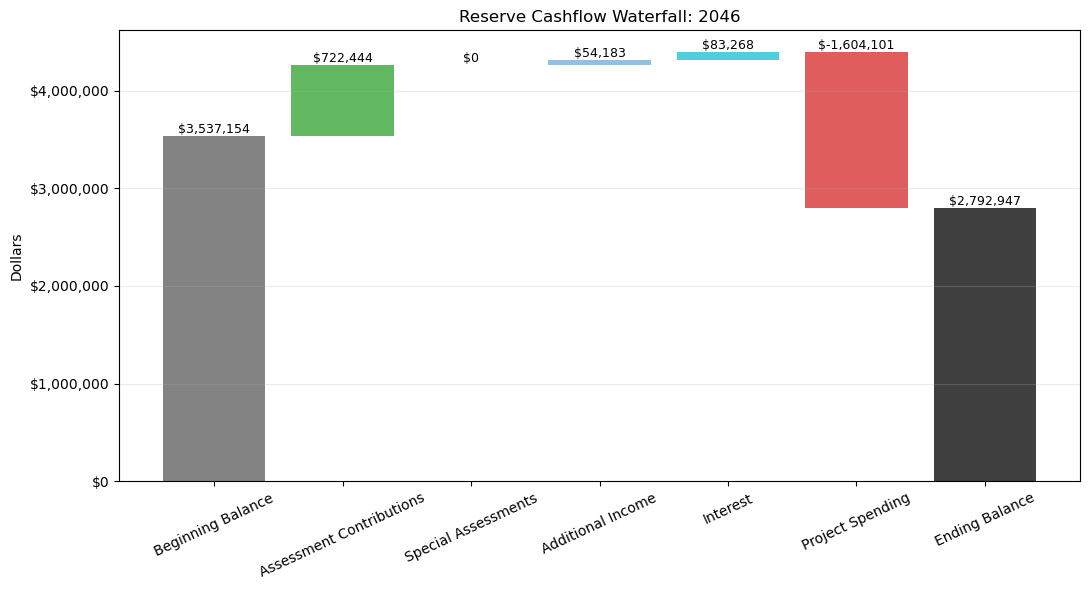

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/reserve_cashflow_waterfall_largest_project_year.pdf')

In [114]:
waterfall_year = int(board_cash_flow.loc[board_cash_flow["expenditures"].idxmax(), "year"])
waterfall_row = board_cash_flow[board_cash_flow["year"] == waterfall_year].iloc[0]
waterfall_steps = pd.DataFrame({
    "label": ["Beginning Balance", "Assessment Contributions", "Special Assessments", "Additional Income", "Interest", "Project Spending", "Ending Balance"],
    "value": [waterfall_row["begin_balance"], waterfall_row["contribution"], waterfall_row["special_assessment"], waterfall_row["additional_income"], waterfall_row["interest"], -waterfall_row["expenditures"], waterfall_row["end_balance"]],
})
waterfall_running = [0.0]
for value in waterfall_steps["value"].iloc[:-1]:
    waterfall_running.append(waterfall_running[-1] + value)
waterfall_steps["bottom"] = [0.0, waterfall_running[1], waterfall_running[2], waterfall_running[3], waterfall_running[4], waterfall_running[5] + waterfall_steps.loc[5, "value"], 0.0]
waterfall_steps["height"] = [waterfall_steps.loc[0, "value"], waterfall_steps.loc[1, "value"], waterfall_steps.loc[2, "value"], waterfall_steps.loc[3, "value"], waterfall_steps.loc[4, "value"], abs(waterfall_steps.loc[5, "value"]), waterfall_steps.loc[6, "value"]]
waterfall_steps["color"] = ["0.35", "#2ca02c", "#ff7f0e", "#6baed6", "#17becf", "#d62728", "black"]
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(waterfall_steps["label"], waterfall_steps["height"], bottom=waterfall_steps["bottom"], color=waterfall_steps["color"], alpha=0.75)
for index, row in waterfall_steps.iterrows():
    ax.text(index, row["bottom"] + row["height"], f"${row['value']:,.0f}", ha="center", va="bottom", fontsize=9)
ax.set_title(f"Reserve Cashflow Waterfall: {waterfall_year}")
ax.set_ylabel("Dollars"); ax.tick_params(axis="x", rotation=25); ax.yaxis.set_major_formatter(money_formatter); ax.grid(True, axis="y", alpha=0.25)
save_pdf(fig, "reserve_cashflow_waterfall_largest_project_year.pdf")


## Top Components Pareto Plot


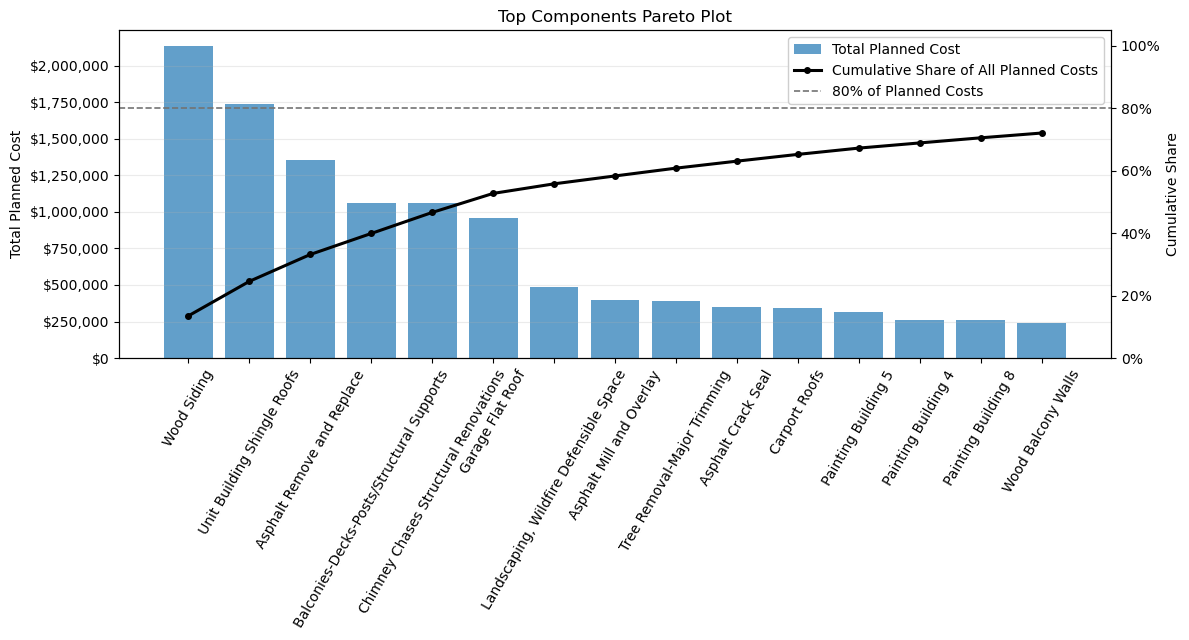

PosixPath('/Users/bgifford/Documents/HOA/Ridge Park Reserve Study OO/runs/2026_board_collab_w_extra_income/plots/top_components_pareto.pdf')

In [115]:
pareto_components = (
    board_maintenance_detail.groupby("component", as_index=False)["future_cost"]
    .sum()
    .sort_values("future_cost", ascending=False)
    .head(15)
)
pareto_components["cumulative_share"] = (
    pareto_components["future_cost"].cumsum() / board_maintenance_detail["future_cost"].sum() * 100.0
)

fig, ax = plt.subplots(figsize=(12, 6.5))
ax2 = ax.twinx()

ax.bar(
    pareto_components["component"],
    pareto_components["future_cost"],
    color="#1f77b4",
    alpha=0.7,
    label="Total Planned Cost",
)
ax2.plot(
    pareto_components["component"],
    pareto_components["cumulative_share"],
    color="black",
    marker="o",
    markersize=4,
    linewidth=2.2,
    label="Cumulative Share of All Planned Costs",
)
ax2.axhline(80, color="0.45", linestyle="--", linewidth=1.2, label="80% of Planned Costs")

ax.set_title("Top Components Pareto Plot")
ax.set_xlabel("")
ax.set_ylabel("Total Planned Cost")
ax2.set_ylabel("Cumulative Share")
ax.tick_params(axis="x", rotation=60)
ax.set_ylim(bottom=0)
ax2.set_ylim(0, 105)
ax.yaxis.set_major_formatter(money_formatter)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(True, axis="y", alpha=0.25)

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper right",
    frameon=True,
    facecolor="white",
    framealpha=0.95,
    edgecolor="0.8",
)

save_pdf(fig, "top_components_pareto.pdf")
